# Notebook 30 — V8 : morphologie / microclimat — visualisation complète et historique généralisé

**Version temporelle (sans GPS)** — Projet ANR CoolPath, Cerema BPE / AAU-CRENAU Nantes

---

## Ce qui change par rapport a la version precedente

La version initiale de ce notebook reliait images et mesures **par la position** (trace GPS
-> abscisse curviligne -> segments de 20 m). Elle etait bloquee : la trace GPS du 11/06 ne
couvrait que 6,5 min sur 45, et aucune acquisition ne combinait les trois flux.

Cette version relie images et mesures **directement par le temps**, ce qui rend le GPS
inutile pour la correlation :

```
frame -> chapitre video + index de frame -> horodatage -> mesure Comfy'Pack
```

| | Version GPS | **Cette version** |
|---|---|---|
| Lien image <-> mesure | via la position | **via l'horodatage** |
| Unite d'agregation | segments de 10/20/50 m | **fenetres de 30/60/120 s** |
| I de Moran | distance spatiale (m) | **distance temporelle (s)** |
| Carte georeferencee, GeoJSON | oui | **non (perdu)** |
| Depend d'une trace GPS complete | oui | **non** |

Ce qui est perdu : la restitution cartographique. Ce qui est conserve : toute la
demonstration statistique (correlations, N effectif, autocorrelation, regression),
qui reste valide sur l'axe temps.

## Le mecanisme de synchronisation

Chaque frame porte son index natif dans son nom (`GS017069[1]_equirect__f008520` -> frame
8520 du chapitre GS017069), ecrit par le notebook 21 (`f"{stem}__f{idx:06d}.jpg"` ou `idx`
est l'index de frame reel lu par OpenCV). D'ou :

$$t_{frame} = T_0(\text{chapitre}) + \frac{idx}{fps}$$

**Verification de coherence effectuee** sur les 1041 frames candidates, avec le fps
**confirme par `exiftool -VideoFrameRate`** (59,94 fps sur les 7 chapitres, pas 60,0
exactement) : l'index maximal de chaque chapitre, divise par ce fps, redonne la duree
annoncee du fichier a moins de 2 s pres, sur les 7 chapitres sans exception.

> **Anomalie initiale resolue.** L'heure de fin de `GS017064` (14:24:32) etait une erreur
> de saisie ; la vraie valeur est **14:26:32**, confirmee par `exiftool -Duration`
> (0:04:15 = 255 s, contre 254,3 s calcules — coherent). Cela ne changeait rien a la
> synchronisation elle-meme : seul `T_0` (le debut) intervient dans le calcul des
> horodatages, et il n'a jamais ete remis en cause.

## Entrees attendues

| Fichier | Produit par | Colonnes utilisees |
|---|---|---|
| `indicateurs_v2/indicateurs_par_image.csv` | nb29 | `image`, `SVF`, `GVI_haute_pct`, `GVI_basse_pct`, `taux_impermeable_pct` |
| `fusion_3models_v2/fusion_par_image.csv` | nb25 | `image`, `albedo_moyen`, `couverture_albedo_pct` |
| `CR1000X_*.csv` | CR1000X (TOA5) | `TIMESTAMP`, `Prt_Ball_*`, `HMP_Temp`, `HMP_RH`, `WS_avg`, `Solspy` |

## References methodologiques

| Bloc | Reference | DOI / lien |
|---|---|---|
| Tmrt depuis globe noir | ISO 7726:1998 | [extrait](https://cdn.standards.iteh.ai/samples/14562/0f8ba16a6e4d454f95d38708649e538a/ISO-7726-1998.pdf) |
| Limites du globe (convection libre) | Teitelbaum et al. 2020, *Sci Rep* 10:2652 | [10.1038/s41598-020-59441-1](https://doi.org/10.1038/s41598-020-59441-1) |
| UTCI | Brode et al. 2012, *Int J Biometeorol* 56:481-494 | [10.1007/s00484-011-0454-1](https://doi.org/10.1007/s00484-011-0454-1) |
| Implementation UTCI | Tartarini & Schiavon 2020, *SoftwareX* 12:100578 | [10.1016/j.softx.2020.100578](https://doi.org/10.1016/j.softx.2020.100578) |
| Inertie capteur en transect mobile | Hab et al. 2015, *Urban Climate* 14:622-635 | [10.1016/j.uclim.2015.10.007](https://doi.org/10.1016/j.uclim.2015.10.007) |
| Autocorrelation | Moran 1950, *Biometrika* 37:17-23 | [10.2307/2332142](https://doi.org/10.2307/2332142) |
| Taille d'echantillon effective (AR1) | Dawdy & Matalas 1964, *Handbook of Applied Hydrology*, sect. 8-I | — |

---

> **V8 — extension demandée en réunion.** L’analyse repose sur les **1041 frames** disponibles.
> Les figures montrent les données à haute résolution temporelle pour comprendre le parcours,
> tandis que l’inférence statistique reste faite sur des fenêtres de 30/60/120 s afin de ne pas
> traiter les frames voisines comme des observations indépendantes. La V8 généralise l’historique
> pondéré à **tous les indicateurs morphologiques**, ajoute `Ta`, `RH` et `v10` aux cibles, et
> produit des visualisations temporelles de type « bandes linéaires » pour relier morphologie et microclimat.


In [1]:
# --- Imports ---
import re, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore", category=UserWarning)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "figure.autolayout": True})

try:
    from pythermalcomfort.models import utci as _utci_model
    HAS_UTCI = True
except ImportError:
    HAS_UTCI = False
    print("pythermalcomfort absent -> UTCI non calcule.")
    print("Installation : pip install pythermalcomfort")

print("pandas", pd.__version__, "| numpy", np.__version__, "| UTCI:", HAS_UTCI)

pandas 2.3.3 | numpy 1.26.4 | UTCI: True


## 1. Configuration

### Parametres a confirmer aupres d'Auline Rodler

Trois constantes du Comfy'Pack conditionnent la validite du Tmrt et ne sont pas documentees.
**Elles ne doivent pas rester aux valeurs par defaut sans verification.**

| Constante | Defaut | Pourquoi c'est critique |
|---|---|---|
| `D_GLOBE` | 0,15 m (ISO 7726) | intervient en `D^-0,4` : un globe de 38 mm change le terme convectif d'un facteur ~1,8 |
| `EPS_GLOBE` | 0,95 | facteur direct sur le terme convectif |
| `Z_ANEMO` | 1,50 m (estimation) | fixe l'extrapolation logarithmique du vent a 10 m exigee par UTCI |

`TA_SOURCE` reste a trancher : `HMP_Temp` (Vaisala, a priori abritee et ventilee, conforme
ISO 7726 §5) ou `Prt_Mid_Temperature_Avg` (sonde platine, plus lisse mais possiblement non
abritee du rayonnement).

### Horaires de debut de chapitre

`T0_CHAPITRES` contient l'heure **locale** de la frame 0 de chaque chapitre, relevee par
comparaison avec les mesures. Le fps est lu directement depuis chaque fichier video
(`cv2.CAP_PROP_FPS`) quand `VIDEO_DIR` est renseigne — sinon `FPS_DEFAUT` s'applique.

In [2]:
# ============================================================
#  CONFIGURATION
# ============================================================
PROJECT_ROOT = Path("..").resolve()
DATA_DIR     = PROJECT_ROOT / "data"
OUTPUT_DIR   = DATA_DIR / "outputs" / "correlation_v8_visualisation_complete"
VIZ_DIR      = OUTPUT_DIR / "viz"
for d in (OUTPUT_DIR, VIZ_DIR):
    d.mkdir(parents=True, exist_ok=True)

# --- Entrees ---------------------------------------------------------------
CSV_INDICATEURS = DATA_DIR / "outputs" / "indicateurs_v2_1041"    / "indicateurs_par_image.csv"
CSV_FUSION      = DATA_DIR / "outputs" / "fusion_3models_v2_1041" / "fusion_par_image.csv"
CSV_COMFY       = DATA_DIR / "raw" / "comfypack" / "CR1000X_00-01_ComfyPackData_2s_20260611_brut.csv"
VIDEO_DIR       = DATA_DIR / "raw" / "video360"   # pour lire le fps reel ; None pour l'ignorer

# --- Synchronisation -------------------------------------------------------
JOUR = "2026-06-11"
T0_CHAPITRES = {           # heure LOCALE de la frame 0 de chaque chapitre
    "GS017064": "14:22:18",
    "GS017065": "14:27:14",
    "GS017066": "14:32:06",
    "GS017067": "14:40:14",
    "GS017068": "14:43:02",
    "GS017069": "14:46:14",
    "GS017070": "14:52:40",
}
FIN_CHAPITRES = {          # sert UNIQUEMENT au controle de coherence (pas au calcul)
    "GS017064": "14:26:32", "GS017065": "14:31:26", "GS017066": "14:39:22",
    "GS017067": "14:42:56", "GS017068": "14:45:40", "GS017069": "14:51:26",
    "GS017070": "15:01:00",
}
# fps CONFIRME par exiftool (-VideoFrameRate) sur les 7 fichiers -- 59.94 partout,
# pas 60.0 : coherence verifiee a moins de 2 s pres sur chaque chapitre (voir §4)
FPS_CONFIRME = {
    "GS017064": 59.94, "GS017065": 59.94, "GS017066": 59.94, "GS017067": 59.94,
    "GS017068": 59.94, "GS017069": 59.94, "GS017070": 59.94,
}
FPS_DEFAUT  = 59.94
REGEX_IMAGE = r"(?P<chapitre>GS\d+).*__f(?P<frame>\d+)"
TOLERANCE_APPARIEMENT_S = 2.0   # ecart max frame <-> mesure (= pas du CR1000X)

# --- Constantes instrumentales (A CONFIRMER) -------------------------------
D_GLOBE   = 0.04      # m    CONFIRME : balle de ping-pong 40mm, peinture "flatgrey"
                     # RAL 7001, selon Thorsson et al. 2017 (soutenance Theo Faurie,
                     # diapo 21). PAS le globe ISO 150mm suppose precedemment --
                     # ecart mesure de 9.4 K sur un cas type avec D=0.15 (voir echange).
EPS_GLOBE = 0.95      # -    non confirme individuellement, mais peinture mate ->
                     # emissivite IR typique 0.90-0.95 quelle que soit la couleur
                     # visible (RAL 7001 = couleur visible, pas emissivite IR)
Z_ANEMO   = 1.50      # m    hauteur de l'anemometre sur le sac
Z0        = 0.01      # m    longueur de rugosite
TA_SOURCE = "HMP_Temp"   # ou "Prt_Mid_Temperature_Avg"

SIGMA_SB = 5.670374419e-8   # W m-2 K-4   CODATA 2018

# --- Parametres d'analyse --------------------------------------------------
FENETRES_S    = [30, 60, 120]    # echelles d'agregation temporelle testees
FENETRE_REF   = 60               # echelle retenue pour figures et modele
TAU_GLOBE_S   = None             # calibre en §7 ; None = calibration automatique
LAG_GLOBE_S   = None
BANDWIDTH_S   = 120.0            # portee du noyau temporel pour le I de Moran

print(f"Sorties -> {OUTPUT_DIR}")
print(f"Globe : D = {D_GLOBE} m, eps = {EPS_GLOBE} | anemometre a {Z_ANEMO} m | Ta = {TA_SOURCE}")
print(f"{len(T0_CHAPITRES)} chapitres video configures")


Sorties -> C:\Users\youss\Downloads\coolpath_local\data\outputs\correlation_v8_visualisation_complete
Globe : D = 0.04 m, eps = 0.95 | anemometre a 1.5 m | Ta = HMP_Temp
7 chapitres video configures


## 2. Chargement du Comfy'Pack

Le CR1000X ecrit au format **TOA5** (Campbell Scientific). Le chargeur detecte
automatiquement les deux structures rencontrees (separateur `;` avec 5 lignes d'en-tete
TOA5, ou export deja mis a plat avec unites entre parentheses).

| Colonne brute | Symbole | Grandeur |
|---|---|---|
| `Prt_Ball_Temperature_Avg` | `Tg` | temperature du globe noir |
| `HMP_Temp` / `HMP_RH` | `Ta` / `RH` | Vaisala HMP : air, humidite relative |
| `WS_avg` / `WindDir_vct` | `WS` / `WD` | anemometre (m/s) et girouette (deg) |
| `Solspy` | `Kdown` | rayonnement solaire global incident, W/m2 |
| `Evenement` | — | marqueurs operateur |

In [3]:
COLMAP = {
    "TIMESTAMP (TS)": "ts",                       "TIMESTAMP": "ts",
    "Prt_Ball_Temperature_Avg (Avg)": "Tg",       "Prt_Ball_Temperature_Avg": "Tg",
    "Prt_Mid_Temperature_Avg (degC) (Avg)": "Prt_Mid",
    "Prt_Mid_Temperature_Avg (Avg)": "Prt_Mid",   "Prt_Mid_Temperature_Avg": "Prt_Mid",
    "HMP_Temp (Smp)": "HMP_Temp",                 "HMP_Temp": "HMP_Temp",
    "HMP_RH (Smp)":   "RH",                       "HMP_RH":   "RH",
    "WS_avg (m/s) (WVc)": "WS",                   "WS_avg":   "WS",
    "WindDir_vct (Deg) (WVc)": "WD",              "WindDir_vct": "WD",
    "Solspy (Smp)": "Kdown",                      "Solspy": "Kdown",
    "Evenement (Smp)": "event",                   "Evenement": "event",
    "Inclinaison_X (Smp)": "inc_x",               "Inclinaison_X": "inc_x",
    "Inclinaison_Y (Smp)": "inc_y",               "Inclinaison_Y": "inc_y",
}
NUM_COLS = ["Tg", "Prt_Mid", "HMP_Temp", "RH", "WS", "WD", "Kdown", "inc_x", "inc_y"]


def load_comfypack(path: Path) -> pd.DataFrame:
    path = Path(path)
    with path.open(encoding="utf-8", errors="replace") as fh:
        first = fh.readline()
    if first.startswith('"TOA5"') or first.startswith("TOA5") or first.count(";") > 3:
        df = pd.read_csv(path, sep=";", skiprows=[0, 3, 4], header=1, encoding="utf-8")
        df.columns = [c.strip().strip('"') for c in df.columns]
    else:
        df = pd.read_csv(path)
    df = df.rename(columns={k: v for k, v in COLMAP.items() if k in df.columns})
    if "ts" not in df.columns:
        raise KeyError(f"Colonne d'horodatage introuvable. Colonnes : {list(df.columns)[:8]}")
    df["ts"] = pd.to_datetime(df["ts"], format="mixed")
    for c in NUM_COLS:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    df["Ta"] = df[TA_SOURCE if TA_SOURCE in df.columns else "HMP_Temp"]
    return df.sort_values("ts").reset_index(drop=True)


cp = load_comfypack(CSV_COMFY)
dt_cp = cp.ts.diff().dt.total_seconds().median()

print(f"Comfy'Pack : {len(cp)} lignes")
print(f"  periode : {cp.ts.min()} -> {cp.ts.max()}  "
      f"({(cp.ts.max()-cp.ts.min()).total_seconds()/60:.1f} min)")
print(f"  pas      : {dt_cp:.1f} s  ({1/dt_cp:.2f} Hz)")
if "event" in cp.columns:
    ev = cp.event.dropna().astype(str)
    ev = ev[ev.str.strip() != ""]
    if len(ev):
        print("  marqueurs :", ", ".join(f"{k} ({v})" for k, v in ev.value_counts().items()))

Comfy'Pack : 1346 lignes
  periode : 2026-06-11 14:16:18 -> 2026-06-11 15:01:08  (44.8 min)
  pas      : 2.0 s  (0.50 Hz)
  marqueurs : Fin Evenement (948), Debut acquisition (309), Debut Evenement (89)


## 3. Controle qualite

Deux traitements distincts, appliques a des variables differentes.

**a) Test de plage physique** — sur toutes les variables. Elimine les valeurs impossibles.

**b) Filtre de gradient + MAD roulante** — **uniquement** sur les variables a inertie
thermique (`Ta`, `Tg`, `Prt_Mid`). Une temperature d'air ne peut pas varier de plusieurs
kelvins en 2 s : un tel saut est un defaut capteur. Le seuil MAD suit Leys et al. (2013),
qui recommandent la deviation absolue mediane plutot que l'ecart-type.

> **`Kdown` n'est jamais deverruisse.** Le pyranometre passe legitimement de 90 a 900 W/m2
> en un pas de temps au franchissement d'une limite d'ombre : ce saut **est le signal**.
> Un filtre MAD sur `Kdown` supprimerait precisement les transitions ombre/soleil que l'on
> cherche a correler au SVF. Meme raisonnement pour `WS` (rafales) et `WD`.

Reference : Leys C. et al. (2013), *Detecting outliers: do not use standard deviation around
the mean, use absolute deviation around the median*, J. Exp. Soc. Psychol. 49(4):764-766,
[10.1016/j.jesp.2013.03.013](https://doi.org/10.1016/j.jesp.2013.03.013)

In [4]:
PLAGES = {"Ta": (-20, 55), "Tg": (-20, 90), "Prt_Mid": (-20, 55), "RH": (0, 100),
          "WS": (0, 40), "WD": (0, 360), "Kdown": (0, 1400),
          "inc_x": (-90, 90), "inc_y": (-90, 90)}
A_DESPIKER   = ["Ta", "Tg", "Prt_Mid"]
GRAD_MAX_K_S = 0.5


def despike_mad(s: pd.Series, window: int = 31, n_mad: float = 5.0):
    med = s.rolling(window, center=True, min_periods=5).median()
    mad = (s - med).abs().rolling(window, center=True, min_periods=5).median()
    seuil = n_mad * 1.4826 * mad          # 1.4826 : MAD -> sigma pour une loi normale
    hors = (s - med).abs() > seuil.replace(0, np.nan)
    return s.mask(hors), int(hors.sum())


rapport_qc = []
for col, (lo, hi) in PLAGES.items():
    if col not in cp.columns:
        continue
    n0 = cp[col].isna().sum()
    cp[col] = cp[col].where(cp[col].between(lo, hi))
    n_plage = cp[col].isna().sum() - n0
    n_grad = n_mad_ = 0
    if col in A_DESPIKER:
        saut = cp[col].diff().abs() / dt_cp > GRAD_MAX_K_S
        n_grad = int(saut.sum())
        cp[col] = cp[col].mask(saut)
        cp[col], n_mad_ = despike_mad(cp[col])
    rapport_qc.append(dict(variable=col, hors_plage=n_plage, gradient=n_grad,
                           mad=n_mad_, pct_perdu=round(cp[col].isna().mean() * 100, 2)))

cp.loc[cp.Ta.isna(), "RH"] = np.nan
cp[["Ta", "Tg", "RH", "WS"]] = cp[["Ta", "Tg", "RH", "WS"]].interpolate(limit=5)
cp["t_min"] = (cp.ts - cp.ts.min()).dt.total_seconds() / 60

df_qc = pd.DataFrame(rapport_qc)
print("=== Controle qualite ===")
print(df_qc.to_string(index=False))
df_qc.to_csv(OUTPUT_DIR / "controle_qualite.csv", index=False)

=== Controle qualite ===
variable  hors_plage  gradient  mad  pct_perdu
      Ta           0         1    1       0.15
      Tg           0         0   36       2.67
 Prt_Mid           0         0   78       5.79
      RH           0         0    0       0.07
      WS           0         0    0       0.00
      WD           0         0    0       0.00
   Kdown           0         0    0       0.00
   inc_x           0         0    0       0.00
   inc_y           0         0    0       0.00


## 4. Horodatage des frames

### Le mecanisme, avec un exemple verifie

$$t_{frame} = T_0(\text{chapitre}) + \frac{idx}{fps}$$

`idx` est l'index de frame natif (ecrit par le notebook 21). Le fps utilise est celui
**confirme par exiftool** (§1), pas une valeur arrondie : `GS017066[1]_equirect__f010920`
donne `10920 / 59,94 = 182,18 s`, soit `14:32:06 + 182 s ≈ 14:35:08` — l'ecart avec
l'approximation "120 frames = 2 s" (qui suppose 60,0 fps exactement) n'est que de 0,18 s,
sans consequence a l'echelle des fenetres d'agregation (30-120 s).

### Controle de coherence automatique

Pour chaque chapitre, on compare la duree impliquee par l'index maximal (`idx_max / fps`)
a la duree annoncee (`FIN - T0`). **Verifie a moins de 2 s sur les 7 chapitres** avec
fps = 59,94 et les horaires corriges.

In [5]:
def lire_fps(chapitre: str) -> float:
    '''fps CONFIRME par exiftool en priorite ; sinon lecture video ; sinon FPS_DEFAUT.'''
    if chapitre in FPS_CONFIRME:
        return FPS_CONFIRME[chapitre]
    if VIDEO_DIR is not None and Path(VIDEO_DIR).exists():
        for motif in (f"{chapitre}*.mp4", f"{chapitre}*.MP4", f"{chapitre}*.360"):
            for v in Path(VIDEO_DIR).glob(motif):
                try:
                    import cv2
                    cap = cv2.VideoCapture(str(v))
                    fps = cap.get(cv2.CAP_PROP_FPS)
                    cap.release()
                    if fps and fps > 1:
                        return float(fps)
                except Exception:
                    pass
    return FPS_DEFAUT


FPS_PAR_CHAPITRE = {ch: lire_fps(ch) for ch in T0_CHAPITRES}


def horodater_images(ind: pd.DataFrame) -> pd.DataFrame:
    '''t_frame = T0(chapitre) + idx / fps, en heure locale.'''
    ind = ind.copy()
    meta = ind["image"].astype(str).str.extract(REGEX_IMAGE)
    if meta.isna().any(axis=None):
        ex = ind.loc[meta.isna().any(axis=1), "image"].iloc[0]
        raise ValueError(f"REGEX_IMAGE ne s'applique pas a {ex!r}")
    ind["chapitre"] = meta["chapitre"]
    ind["frame"] = meta["frame"].astype(int)

    inconnus = sorted(set(ind.chapitre) - set(T0_CHAPITRES))
    if inconnus:
        n = ind.chapitre.isin(inconnus).sum()
        print(f"  !! T0 inconnu pour {inconnus} -> {n} images exclues")
        ind = ind[~ind.chapitre.isin(inconnus)]

    t0 = ind.chapitre.map({c: pd.Timestamp(f"{JOUR} {h}") for c, h in T0_CHAPITRES.items()})
    fps = ind.chapitre.map(FPS_PAR_CHAPITRE)
    ind["ts"] = t0 + pd.to_timedelta(ind.frame / fps, unit="s")
    return ind.sort_values("ts").reset_index(drop=True)


def controle_coherence(ind: pd.DataFrame):
    '''Duree impliquee par idx_max/fps vs duree annoncee, par chapitre.

    N'alerte QUE si la duree calculee DEPASSE la duree annoncee (au-dela d'une
    marge) : c'est le seul cas qui signale une vraie incoherence T0/fps. Une
    duree calculee plus COURTE que l'annoncee est normale et attendue des que
    `ind` peut contenir un sous-ensemble des frames du chapitre -- alerter dans ce
    cas produirait de fausses alarmes systematiques, sans rapport avec un
    probleme reel de synchronisation.
    '''
    MARGE_S = 15
    lignes = []
    for ch, g in ind.groupby("chapitre"):
        fps = FPS_PAR_CHAPITRE[ch]
        idx_max = int(g.frame.max())
        d_calc = idx_max / fps
        t0 = pd.Timestamp(f"{JOUR} {T0_CHAPITRES[ch]}")
        d_ann = np.nan
        if ch in FIN_CHAPITRES:
            d_ann = (pd.Timestamp(f"{JOUR} {FIN_CHAPITRES[ch]}") - t0).total_seconds()
        lignes.append(dict(chapitre=ch, n_frames=len(g), fps=fps, idx_max=idx_max,
                           duree_calculee_s=round(d_calc), duree_annoncee_s=d_ann,
                           ecart_s=round(d_calc - d_ann) if np.isfinite(d_ann) else np.nan))
    t = pd.DataFrame(lignes)
    t["coherent"] = np.where(t.ecart_s > MARGE_S, "NON", "oui")
    return t


# Colonnes materiaux retenues de fusion_par_image.csv (nb25 v5) : seulement celles
# avec une vraie variance sur le jeu d’images de référence -- pct_Natural_Stone, pct_Brick,
# pct_Roof_tile, pct_Sand sont quasi constantes (std < 0.05, cf. verification faite
# sur le CSV reel) et n'apporteraient rien a une correlation.
COLS_MATERIAUX = ["pct_Asphalt", "pct_Cement_Concrete", "pct_Soil_Mud",
                  "pct_Glass", "pct_Metal", "pct_Paint"]

ind = pd.read_csv(CSV_INDICATEURS)
if CSV_FUSION.exists():
    fus = pd.read_csv(CSV_FUSION)
    garder = ["image"] + [c for c in ["albedo_moyen", "couverture_albedo_pct",
                                      "pct_corriges_gating"] + COLS_MATERIAUX
                          if c in fus.columns]
    manquantes = [c for c in COLS_MATERIAUX if c not in fus.columns]
    if manquantes:
        print(f"  !! colonnes materiaux absentes de {CSV_FUSION.name} : {manquantes}")
        print("     (nb25 doit etre relance avec la v5 mise a jour pour les produire)")
    ind = ind.merge(fus[garder], on="image", how="left")
else:
    print(f"  {CSV_FUSION.name} absent : indicateurs d'albedo non disponibles.")

print(f"Indicateurs : {len(ind)} images")
print("fps par chapitre :", {k: round(v, 2) for k, v in FPS_PAR_CHAPITRE.items()})

ind = horodater_images(ind)
coh = controle_coherence(ind)
print("\n=== Controle de coherence chapitre par chapitre ===")
print(coh.to_string(index=False))
coh.to_csv(OUTPUT_DIR / "controle_coherence_chapitres.csv", index=False)

if (coh.coherent == "NON").any():
    mauvais = coh.loc[coh.coherent == "NON", "chapitre"].tolist()
    print(f"\n  !! {mauvais} : la duree calculee DEPASSE la duree annoncee du chapitre.")
    print("     Ca signale un vrai probleme (T0 ou fps errone) -- a la difference d'une")
    print("     duree calculee plus courte, normale sur un sous-ensemble de frames.")

print(f"\nFrames horodatees : {ind.ts.min()} -> {ind.ts.max()}")


Indicateurs : 1041 images
fps par chapitre : {'GS017064': 59.94, 'GS017065': 59.94, 'GS017066': 59.94, 'GS017067': 59.94, 'GS017068': 59.94, 'GS017069': 59.94, 'GS017070': 59.94}

=== Controle de coherence chapitre par chapitre ===
chapitre  n_frames   fps  idx_max  duree_calculee_s  duree_annoncee_s  ecart_s coherent
GS017064       128 59.94    15240               254             254.0        0      oui
GS017065       126 59.94    15120               252             252.0        0      oui
GS017066       220 59.94    26280               438             436.0        2      oui
GS017067        81 59.94     9600               160             162.0       -2      oui
GS017068        79 59.94     9360               156             158.0       -2      oui
GS017069       156 59.94    18600               310             312.0       -2      oui
GS017070       251 59.94    30000               501             500.0        1      oui

Frames horodatees : 2026-06-11 14:22:18 -> 2026-06-11 15:01:00.

## 5. Appariement frames <-> mesures

Chaque frame est rattachee a la mesure Comfy'Pack la plus proche dans le temps, avec une
tolerance de 2 s — soit exactement le pas d'echantillonnage du CR1000X. Une frame sans
mesure dans cette fenetre est ecartee plutot que rattachee de force a une mesure lointaine.

L'appariement se fait dans ce sens (frame -> mesure) et non l'inverse : les mesures sont
la reference physique, les frames viennent s'y rattacher.

In [6]:
avant = len(ind)
ind["ts"] = ind["ts"].astype("datetime64[ns]")   # aligne la precision avec cp.ts (merge_asof
cp["ts"]  = cp["ts"].astype("datetime64[ns]")    # exige des dtypes identiques, ns ou us)
ind = pd.merge_asof(
    ind.sort_values("ts"),
    cp[["ts"]].assign(_mesure=True).sort_values("ts"),
    on="ts", direction="nearest",
    tolerance=pd.Timedelta(seconds=TOLERANCE_APPARIEMENT_S),
)
orphelines = ind._mesure.isna().sum()
ind = ind[ind._mesure.notna()].drop(columns="_mesure").reset_index(drop=True)

print(f"Frames appariees : {len(ind)} / {avant}  ({orphelines} orphelines, "
      f"ecart > {TOLERANCE_APPARIEMENT_S:.0f} s)")

hors_fenetre = ~ind.ts.between(cp.ts.min(), cp.ts.max())
if hors_fenetre.any():
    print(f"  !! {hors_fenetre.sum()} frames hors de la fenetre de mesures")

COLS_IND = [c for c in ["SVF", "GVI_haute_pct", "GVI_basse_pct", "taux_impermeable_pct",
                        "albedo_moyen", "canopee_sol_non_observable_pct",
                        "taux_bati_pct"] + COLS_MATERIAUX
            if c in ind.columns]
# taux_bati_pct (nb29) N'EST PAS dans COLS_MATERIAUX -> reste dans PREDICTEURS (regression,
# cf. plus bas) contrairement aux 6 materiaux. Justifie par la corrélation mesurée avec
# GVI_haute_pct (r=-0.53, modere) -- rien a voir avec l'extreme deja vu sur pct_Paint
# (r=-0.72) ou GVI_haute/canopee_sol_non_observable (VIF 306 000). Le diagnostic VIF
# de la regression (plus bas) confirmera si c'est effectivement sans danger.
print(f"Indicateurs retenus : {COLS_IND}")

ecarts = ind.ts.diff().dt.total_seconds().dropna()
print(f"\nDensite temporelle : ecart median {ecarts.median():.0f} s "
      f"(min {ecarts.min():.0f} s, max {ecarts.max():.0f} s)")
print("Nombre de segments selon la fenetre :")
for fen in FENETRES_S:
    n = ((ind.ts - ind.ts.min()).dt.total_seconds() // fen).nunique()
    print(f"  {fen:3d} s -> N = {n:3d} segments  ({len(ind)/n:.1f} frames/segment)")

Frames appariees : 1041 / 1041  (0 orphelines, ecart > 2 s)
Indicateurs retenus : ['SVF', 'GVI_haute_pct', 'GVI_basse_pct', 'taux_impermeable_pct', 'albedo_moyen', 'canopee_sol_non_observable_pct', 'taux_bati_pct', 'pct_Asphalt', 'pct_Cement_Concrete', 'pct_Soil_Mud', 'pct_Glass', 'pct_Metal', 'pct_Paint']

Densite temporelle : ecart median 2 s (min 2 s, max 76 s)
Nombre de segments selon la fenetre :
   30 s -> N =  77 segments  (13.5 frames/segment)
   60 s -> N =  39 segments  (26.7 frames/segment)
  120 s -> N =  20 segments  (52.0 frames/segment)


## 6. Temperature moyenne radiante (ISO 7726:1998)

$$T_{mrt} = \left[(T_g + 273{,}15)^4 + \frac{h_{cg}}{\varepsilon\,\sigma_{SB}}\,(T_g - T_a)\right]^{1/4} - 273{,}15$$

Le coefficient d'echange convectif prend deux formes selon le regime (§B.2.2) :

$$h_{cg}^{\text{libre}} = 1{,}4\left(\frac{|T_g - T_a|}{D}\right)^{1/4}
\qquad
h_{cg}^{\text{forcee}} = 6{,}3\,\frac{v_a^{0{,}6}}{D^{0{,}4}}$$

**Le critere de selection est le maximum des deux.** On implemente la forme generale en
$h_{cg}$, valable pour tout diametre, plutot que la constante $1{,}10\times10^8$ tabulee
pour D = 0,15 m (les deux ecritures different de 0,19 K sur un cas type).

### Limite a documenter

Teitelbaum et al. (2020, 2022) montrent que le traitement ISO de la convection libre est
insuffisant et que **les globes de petit diametre presentent un biais convectif stochastique**.
Avec `D_GLOBE` desormais confirme a 0,04 m (une balle de ping-pong, tres en dessous du globe
ISO 150 mm), cette limite s'applique pleinement ici -- a documenter explicitement dans le
rapport comme une incertitude structurelle du Tmrt, pas seulement une hypothese a verifier.

In [7]:
def tmrt_iso7726(Tg, Ta, va, D=D_GLOBE, eps=EPS_GLOBE):
    '''Tmrt (degC) selon ISO 7726:1998 §B.2.2, regime convectif selectionne par max(h_cg).'''
    Tg = np.asarray(Tg, float); Ta = np.asarray(Ta, float)
    va = np.clip(np.asarray(va, float), 0.0, None)
    dT = Tg - Ta

    h_libre  = 1.4 * (np.abs(dT) / D) ** 0.25
    h_forcee = 6.3 * va ** 0.6 / D ** 0.4
    forcee   = h_forcee >= h_libre
    h_cg     = np.where(forcee, h_forcee, h_libre)

    T4 = (Tg + 273.15) ** 4 + h_cg / (eps * SIGMA_SB) * dT
    T4 = np.where(T4 > 0, T4, np.nan)
    return T4 ** 0.25 - 273.15, forcee


cp["Tmrt"], regime_forcee = tmrt_iso7726(cp.Tg, cp.Ta, cp.WS)
cp["dTmrt_Ta"] = cp.Tmrt - cp.Ta

print("=== Tmrt (ISO 7726:1998) ===")
print(f"  regime forcee : {np.nanmean(regime_forcee)*100:.0f} % des pas de temps")
print(f"  Tmrt          : min {cp.Tmrt.min():5.1f} | med {cp.Tmrt.median():5.1f} | "
      f"p99 {cp.Tmrt.quantile(.99):5.1f} | max {cp.Tmrt.max():5.1f} degC")
print(f"  Tmrt - Ta     : med {cp.dTmrt_Ta.median():5.1f} | p99 {cp.dTmrt_Ta.quantile(.99):5.1f} K")

hors = (cp.dTmrt_Ta < -30) | (cp.dTmrt_Ta > 70)
if hors.any():
    print(f"\n  {hors.sum()} pas de temps hors du domaine de validite UTCI "
          f"(-30 K <= Tmrt-Ta <= +70 K)")
    print("  Typiquement des decrochages residuels de Ta, la formule ISO amplifiant")
    print("  fortement tout ecart Tg-Ta anormalement grand.")

=== Tmrt (ISO 7726:1998) ===
  regime forcee : 99 % des pas de temps
  Tmrt          : min   9.8 | med  32.7 | p99  48.8 | max  53.8 degC
  Tmrt - Ta     : med  12.0 | p99  28.1 K


## 7. Vent de reference et UTCI

$$v_{10} = v_z \cdot \frac{\ln(10/z_0)}{\ln(z/z_0)}$$

Avec z = 1,50 m et z0 = 0,01 m, le facteur vaut **1,38**. C'est une approximation :
l'ecoulement dans la canopee urbaine ne suit pas un profil logarithmique, il est domine
par la geometrie locale et la turbulence. A signaler comme limite.

| Variable | Bornes de validite UTCI |
|---|---|
| $v_{10}$ | 0,5 a 17 m/s |
| $T_{mrt} - T_a$ | -30 a +70 K |

Les pas hors domaine sont mis a NaN par `pythermalcomfort` (`limit_inputs=True`) plutot
qu'extrapoles — comportement correct qu'on conserve.

In [8]:
cp["v10"] = cp.WS * np.log(10 / Z0) / np.log(Z_ANEMO / Z0)
facteur = np.log(10 / Z0) / np.log(Z_ANEMO / Z0)

print(f"Facteur d'extrapolation {Z_ANEMO} m -> 10 m : x{facteur:.2f}")
print(f"  v10 : med {cp.v10.median():.2f} | p95 {cp.v10.quantile(.95):.2f} m/s")
print(f"  sous 0.5 m/s : {(cp.v10 < 0.5).mean()*100:.1f} % (bornes a 0.5)")

if HAS_UTCI:
    res = _utci_model(tdb=cp.Ta.to_numpy(float), tr=cp.Tmrt.to_numpy(float),
                      v=cp.v10.clip(0.5, 17).to_numpy(float), rh=cp.RH.to_numpy(float),
                      limit_inputs=True, round_output=False)
    cp["UTCI"] = np.asarray(res.utci, dtype=float)
    print(f"\nUTCI : med {np.nanmedian(cp.UTCI):.1f} degC | "
          f"p5 {np.nanpercentile(cp.UTCI,5):.1f} | p95 {np.nanpercentile(cp.UTCI,95):.1f}")
    print(f"  {int(np.isnan(cp.UTCI).sum())} valeurs NaN (hors domaine de validite)")

    bornes = [-np.inf, 9, 26, 32, 38, 46, np.inf]
    libelles = ["pas de stress ou stress froid", "pas de stress thermique",
                "stress modere", "stress fort", "stress tres fort", "stress extreme"]
    cat = pd.cut(cp.UTCI, bins=bornes, labels=libelles)
    print("\n  Categories de stress (Brode et al. 2012, Tab. 3) :")
    for k, v in cat.value_counts().sort_index().items():
        if v:
            print(f"    {k:<32} {v/len(cp)*100:5.1f} %")
else:
    cp["UTCI"] = np.nan
    print("\nUTCI non calcule (pythermalcomfort absent).")

Facteur d'extrapolation 1.5 m -> 10 m : x1.38
  v10 : med 2.27 | p95 4.93 m/s
  sous 0.5 m/s : 3.2 % (bornes a 0.5)

UTCI : med 21.9 degC | p5 17.4 | p95 24.1
  11 valeurs NaN (hors domaine de validite)

  Categories de stress (Brode et al. 2012, Tab. 3) :
    pas de stress thermique           99.2 %


## 8. Calibration de l'inertie du globe

### Pourquoi ce bloc conditionne tout le reste

Sur le jeu du 06/07/2026, la correlation entre la temperature du globe et le rayonnement
mesure **au meme instant** valait **r = 0,018**. Point par point, le globe ne « voit » pas
le rayonnement instantane : il integre l'historique thermique des minutes precedentes.

**Consequence directe : une correlation image-par-image entre SVF et Tmrt ne peut pas
fonctionner.** Il faut correler la fenetre morphologique **passee** avec la mesure presente.

### Formalisation

Reponse du globe modelisee comme un premier ordre — filtre exponentiel de constante $\tau_c$,
suivi d'un retard pur $\ell$ :

$$X_k = a\,X_{k-1} + (1-a)\,K_k, \qquad a = e^{-\Delta t/\tau_c}$$

$\tau_c$ et $\ell$ sont determines par balayage, en maximisant $r$ entre $T_g$ et $X$.
**Les deux series sont detendancees au prealable** : sans cela, l'optimum derive vers les
grands $\tau_c$, le filtre absorbant simplement la derive diurne plutot que la reponse au
rayonnement.

Resultat obtenu sur le jeu du 06/07 : **tau = 120 s, lag = 60 s, r = 0,866** (contre 0,018
en instantane), optimum net et interieur au domaine balaye. Coherent avec les protocoles
de transect mobile publies, qui imposent des arrets de 45 s a 5 min par point pour laisser
le globe s'equilibrer (Hab et al. 2015 ; Middel & Krayenhoff 2019).

Le balayage est refait ici sur le jeu courant — la valeur peut differer.

In [9]:
def historique_exp(valeurs, dt_s: float, tau_s: float) -> np.ndarray:
    '''Moyenne mobile exponentielle causale de constante de temps tau_s.'''
    a = np.exp(-dt_s / tau_s)
    v = np.asarray(valeurs, float)
    out = np.empty_like(v)
    acc = v[0] if np.isfinite(v[0]) else np.nanmean(v)
    for i, x in enumerate(v):
        if np.isfinite(x):
            acc = a * acc + (1 - a) * x
        out[i] = acc
    return out


def detendancer(v, t):
    v = np.asarray(v, float); t = np.asarray(t, float)
    m = np.isfinite(v) & np.isfinite(t)
    if m.sum() < 3:
        return v
    return v - np.polyval(np.polyfit(t[m], v[m], 1), t)


TAUS = [30, 60, 120, 180, 240, 300, 420]
LAGS = [0, 30, 60, 90, 120, 180]

t_s = cp.t_min.to_numpy() * 60
Tg_d = detendancer(cp.Tg, t_s)
K = cp.Kdown.to_numpy(float)

grille = pd.DataFrame(index=[f"{t} s" for t in TAUS], columns=[f"{l} s" for l in LAGS],
                      dtype=float)
meilleur = (-np.inf, None, None)
for tau in TAUS:
    Xd = detendancer(historique_exp(K, dt_cp, tau), t_s)
    for lag in LAGS:
        r = pd.Series(Tg_d).corr(pd.Series(Xd).shift(int(round(lag / dt_cp))))
        grille.loc[f"{tau} s", f"{lag} s"] = r
        if np.isfinite(r) and r > meilleur[0]:
            meilleur = (r, tau, lag)

r_opt, TAU_OPT, LAG_OPT = meilleur
TAU_GLOBE_S = TAU_GLOBE_S or TAU_OPT
LAG_GLOBE_S = LAG_GLOBE_S if LAG_GLOBE_S is not None else LAG_OPT

print("=== r(Tg detendance, historique(Kdown) detendance) ===")
print(grille.round(3).to_string())
print(f"\nOptimum : tau = {TAU_OPT} s, lag = {LAG_OPT} s -> r = {r_opt:.3f}")
print(f"  r instantane (tau->0, lag=0) : {cp[['Tg','Kdown']].corr().iloc[0,1]:.3f}")

if TAU_OPT == max(TAUS) or LAG_OPT == max(LAGS):
    print("\n  !! Optimum en BORD de grille : le vrai optimum est peut-etre au-dela.")
    print("     Elargir TAUS/LAGS, ou considerer que la duree du parcours est trop")
    print("     courte pour contenir assez de cycles ombre/soleil (cas du 11/06 : 408 m).")

grille.to_csv(OUTPUT_DIR / "calibration_inertie_globe.csv")

n_lag = int(round(LAG_GLOBE_S / dt_cp))
cp["Kdown_hist"] = pd.Series(historique_exp(K, dt_cp, TAU_GLOBE_S)).shift(n_lag).to_numpy()

=== r(Tg detendance, historique(Kdown) detendance) ===
         0 s   30 s   60 s   90 s  120 s  180 s
30 s   0.427  0.644  0.731  0.676  0.536  0.196
60 s   0.658  0.809  0.816  0.697  0.511  0.143
120 s  0.815  0.861  0.782  0.607  0.391  0.020
180 s  0.806  0.796  0.682  0.492  0.275 -0.078
240 s  0.757  0.719  0.592  0.400  0.190 -0.139
300 s  0.706  0.655  0.522  0.335  0.133 -0.175
420 s  0.630  0.567  0.435  0.258  0.072 -0.203

Optimum : tau = 120 s, lag = 30 s -> r = 0.861
  r instantane (tau->0, lag=0) : 0.110


## 8bis. Morphologie historique (`GVI_hist`, `SVF_hist`)

### L'asymétrie que ce bloc corrige

Le §8 a établi que le globe intègre l'historique radiatif : la corrélation avec le
rayonnement passe de r ≈ 0,11 (instantané) à r ≈ 0,86 avec τ = 120 s. Le notebook
applique donc déjà cette mémoire à `Kdown` → `Kdown_hist`.

**Mais les indicateurs morphologiques, eux, restent instantanés** (médiane des images
de la fenêtre courante). On compare donc une réponse thermique *avec* mémoire à une
morphologie *sans* mémoire. La Tmrt mesurée à l'instant *t* dépend de la rue traversée
pendant les minutes précédentes, pas de ce que voit la caméra exactement à *t*.

### ⚠️ Ce que τ = 120 s représente vraiment (et ce qu'il ne représente pas)

τ a été obtenu en maximisant la corrélation `Kdown_hist` ↔ **Tg** (§8). Or **Tmrt est
calculé à partir de Tg**. Améliorer l'alignement de la morphologie avec la mémoire de
Tg améliore donc mécaniquement son alignement avec Tmrt : τ n'est pas indépendant de
la cible thermique.

**Formulation correcte** : « prise en compte de l'historique d'exposition, compatible
avec la dynamique temporelle du globe ».
**Formulation à éviter** : « l'environnement urbain possède une inertie thermique de
120 s » — ce n'est pas ce qui est démontré ici ; 120 s caractérise la réponse du
*capteur*, pas celle de la ville.

Ce qui reste non trivial malgré cette réserve : l'historique **dégrade** les
corrélations avec `Kdown` tout en améliorant celles avec Tmrt/UTCI. Un simple effet
de lissage améliorerait les deux indistinctement.

### Paramètres : τ et le retard ne sont PAS ré-optimisés

`τ = 120 s` et `lag = 30 s` sont repris **tels quels** de la calibration physique
Kdown → Tg (§8). Les balayer à nouveau en maximisant r(GVI_hist, Tmrt) reviendrait à
sélectionner le résultat le plus favorable — c'est-à-dire du p-hacking. Utiliser des
valeurs obtenues indépendamment, sur une autre paire de variables, est bien plus
défendable.

### Un piège technique : le pas de temps n'est pas constant

`Kdown` est échantillonné toutes les 2 s régulièrement, mais **les images ne le sont
pas** : il existe des trous de 6 à 74 s entre les chapitres vidéo (248 s au total sur
39 min de parcours), pendant lesquels le porteur marchait mais ne filmait pas.

Une EMA à pas fixe traiterait la dernière image d'un chapitre comme immédiatement
suivie de la première image du suivant. Sur un trou de 74 s, l'erreur est majeure :
la mémoire survivante passerait de 54 % (correct) à 98 % (faux). Ce bloc utilise donc
un **Δt variable** :

$$a_i = e^{-\Delta t_i / \tau}, \qquad \Delta t_i = t_i - t_{i-1}$$

⚠️ **Limite à documenter** : la décroissance à travers les trous est correcte, mais la
morphologie réellement traversée pendant ces 248 s reste inconnue.

### Le test décisif

Comparer `GVI_hist` vs `GVI_courant` **à résolution temporelle constante** (60 s).
C'est un protocole plus propre que de comparer 30/60/120 s : passer à une fenêtre plus
large lisse le bruit *et* réduit N (77 → 39 → 20), donc une hausse de |r| ne prouverait
pas l'inertie à elle seule.

In [10]:
# =============================================================================
# MORPHOLOGIE HISTORIQUE -- EMA a pas de temps VARIABLE
# =============================================================================
def historique_exp_dt_variable(valeurs, t_s, tau_s: float) -> np.ndarray:
    '''EMA causale a pas de temps variable : a_i = exp(-(t_i - t_{i-1}) / tau).

    Contrairement a historique_exp() (§8, pas fixe, adapte au CR1000X qui
    echantillonne regulierement toutes les 2 s), cette version gere les trous
    entre chapitres video (6 a 74 s). Sur un trou de 74 s, un pas fixe donnerait
    98 % de memoire survivante au lieu de 54 % -- erreur de 0,44 en valeur
    normalisee (verifie par test).
    '''
    v = np.asarray(valeurs, float)
    t = np.asarray(t_s, float)
    out = np.empty_like(v)
    acc = v[0] if np.isfinite(v[0]) else np.nanmean(v)
    out[0] = acc
    for i in range(1, len(v)):
        a = np.exp(-max(t[i] - t[i - 1], 0.0) / tau_s)
        if np.isfinite(v[i]):
            acc = a * acc + (1 - a) * v[i]
        out[i] = acc
    return out


def appliquer_retard(serie, t_s, lag_s: float) -> np.ndarray:
    '''Valeur de la serie a l'instant (t - lag), par interpolation lineaire --
    necessaire car les instants ne sont pas regulierement espaces.'''
    t = np.asarray(t_s, float)
    return np.interp(t - lag_s, t, np.asarray(serie, float))


# --- Validation : echelon, puis trou de 74 s ---
print("=== Validation de historique_exp_dt_variable() ===")
_t = np.arange(0, 600, 2.0)
_v = np.where(_t < 100, 0.0, 1.0)
_h = historique_exp_dt_variable(_v, _t, 120.0)
_i = np.argmin(np.abs(_t - 220.0))
print(f"  echelon, valeur a t=tau apres le saut : {_h[_i]:.3f}  (0,632 attendu)")
assert abs(_h[_i] - 0.632) < 0.02

_t2 = np.array([0.0, 2.0, 4.0, 78.0])          # trou de 74 s
_h2 = historique_exp_dt_variable(np.array([1.0, 1.0, 1.0, 0.0]), _t2, 120.0)
print(f"  trou de 74 s, memoire survivante      : {_h2[-1]:.3f}  "
      f"(exp(-74/120) = {np.exp(-74/120):.3f} attendu)")
assert abs(_h2[-1] - np.exp(-74 / 120)) < 1e-3
print("  2/2 tests passes\n")


# --- Construction des indicateurs historiques (tau et lag repris du §8) ---
ind = ind.sort_values("ts").reset_index(drop=True)
_t_frames = (ind.ts - ind.ts.min()).dt.total_seconds().to_numpy()

# V8 : on historise TOUS les indicateurs morphologiques courants disponibles.
# Important : tau/lag restent ceux calibres uniquement sur Kdown -> Tg ; ils ne sont
# JAMAIS re-optimises indicateur par indicateur. Il s'agit d'un historique pondere
# d'exposition, pas d'une constante d'inertie propre a chaque materiau.
COLS_IND_COURANTS = list(COLS_IND)
MORPHO_A_HISTORISER = []
for c in COLS_IND_COURANTS:
    v = pd.to_numeric(ind[c], errors="coerce").to_numpy(float)
    if np.isfinite(v).sum() >= 5 and np.nanstd(v) > 1e-12:
        MORPHO_A_HISTORISER.append(c)

COLS_HIST = []
for col in MORPHO_A_HISTORISER:
    h = historique_exp_dt_variable(ind[col].to_numpy(float), _t_frames, TAU_GLOBE_S)
    ind[f"{col}_hist"] = appliquer_retard(h, _t_frames, LAG_GLOBE_S)
    COLS_HIST.append(f"{col}_hist")

COLS_IND = COLS_IND_COURANTS + [c for c in COLS_HIST if c not in COLS_IND_COURANTS]

print(f"tau = {TAU_GLOBE_S} s, lag = {LAG_GLOBE_S} s  (repris du §8, NON re-optimises)")
print(f"{len(COLS_IND_COURANTS)} indicateurs courants")
print(f"{len(COLS_HIST)} indicateurs historises : {COLS_HIST}")

# --- Diagnostic des trous entre chapitres ---
_ecarts = np.diff(_t_frames)
_gros = _ecarts[_ecarts > 10]
print(f"\nTrous > 10 s entre images consecutives : {len(_gros)} "
      f"(total {_gros.sum():.0f} s, max {_gros.max():.0f} s)")
print(f"  memoire survivante au plus grand trou : {np.exp(-_gros.max()/TAU_GLOBE_S)*100:.0f} %")
print("  (la decroissance est correcte, mais la morphologie traversee pendant")
print("   ces intervalles reste inconnue -- limite a documenter)")

# --- Marquage des historiques non fiables apres un gros trou -----------------
# Correction : l'EMA donne un poids (1-a) a la PREMIERE observation suivant un
# trou, comme si cette morphologie avait rempli tout l'intervalle inconnu. Sur
# un trou de 76 s, ce poids "fabrique" atteint 47 %. La decroissance de la
# memoire ancienne est correcte, mais ce remplissage est une hypothese, pas une
# mesure. On marque donc NaN tant que le poids fabrique depasse SEUIL_FABRIQUE.
GAP_MAX_S = 20.0        # au-dela, on considere qu'il y a un vrai trou
SEUIL_FABRIQUE = 0.20   # part maximale toleree d'information fabriquee

def fenetres_non_fiables(t_s, tau_s, gap_max=GAP_MAX_S, seuil=SEUIL_FABRIQUE):
    """Intervalles [debut, fin] ou le poids fabrique par un trou depasse seuil."""
    t = np.asarray(t_s, float)
    fenetres = []
    for i, dt in enumerate(np.diff(t), start=1):
        if dt <= gap_max:
            continue
        w0 = 1.0 - np.exp(-dt / tau_s)
        if w0 <= seuil:
            continue
        duree = tau_s * np.log(w0 / seuil)
        fenetres.append((t[i], t[i] + duree))
    return fenetres


def marquer_apres_trous(t_query, fenetres, lag_s=0.0):
    """True = fiable. CORRECTION : une valeur interrogee a t_query (apres le
    retard `lag_s`) lit en realite la source EMA a (t_query - lag_s) -- donc
    la fenetre non fiable doit etre decalee de +lag_s dans le referentiel de
    t_query, sinon la contamination d'un trou "fuit" au-dela de la fenetre
    marquee (verifie : 34/36 points mal classes sans ce decalage, sur un cas
    type)."""
    t_query = np.asarray(t_query, float)
    fiable = np.ones(len(t_query), bool)
    for (d, f) in fenetres:
        fiable &= ~((t_query >= d + lag_s) & (t_query < f + lag_s))
    return fiable


_fenetres = fenetres_non_fiables(_t_frames, TAU_GLOBE_S)
_fiable = marquer_apres_trous(_t_frames, _fenetres, lag_s=LAG_GLOBE_S)
for col in COLS_HIST:
    ind.loc[~_fiable, col] = np.nan

_pct = (~_fiable).mean() * 100
print(f"\nMarquage des trous : {(~_fiable).sum()} frames sur {len(_fiable)} "
      f"({_pct:.0f} %) ecartees des indicateurs historiques")
print(f"  (poids fabrique > {SEUIL_FABRIQUE:.0%} apres un trou > {GAP_MAX_S:.0f} s)")
print("  -> les valeurs historiques restantes ne dependent plus majoritairement")
print("     d'une morphologie inconnue interpolee a travers un trou.")


=== Validation de historique_exp_dt_variable() ===
  echelon, valeur a t=tau apres le saut : 0.638  (0,632 attendu)
  trou de 74 s, memoire survivante      : 0.540  (exp(-74/120) = 0.540 attendu)
  2/2 tests passes

tau = 120 s, lag = 30 s  (repris du §8, NON re-optimises)
13 indicateurs courants
13 indicateurs historises : ['SVF_hist', 'GVI_haute_pct_hist', 'GVI_basse_pct_hist', 'taux_impermeable_pct_hist', 'albedo_moyen_hist', 'canopee_sol_non_observable_pct_hist', 'taux_bati_pct_hist', 'pct_Asphalt_hist', 'pct_Cement_Concrete_hist', 'pct_Soil_Mud_hist', 'pct_Glass_hist', 'pct_Metal_hist', 'pct_Paint_hist']

Trous > 10 s entre images consecutives : 5 (total 243 s, max 76 s)
  memoire survivante au plus grand trou : 53 %
  (la decroissance est correcte, mais la morphologie traversee pendant
   ces intervalles reste inconnue -- limite a documenter)

Marquage des trous : 144 frames sur 1041 (14 %) ecartees des indicateurs historiques
  (poids fabrique > 20% apres un trou > 20 s)
  -> le

## 9. Agregation en fenetres temporelles

### Le choix d'echelle n'est pas neutre

Avec les 1041 frames disponibles sur ce parcours :

| Fenetre | N segments | frames/segment | Risque |
|---|---|---|---|
| 30 s | 56 | 2,1 | le globe n'a pas eu le temps de reagir |
| **60 s** | **35** | **3,3** | compromis retenu |
| 120 s | 19 | 6,1 | correspond a tau du globe, mais N trop faible |

**Aucune de ces valeurs n'est confortable.** A 120 s — la constante de temps du globe — il
ne reste que 19 segments, et le N effectif apres correction d'autocorrelation tombera plus
bas encore. C'est l'argument central pour passer aux 1041 frames candidates : meme parcours,
~9x plus de points, donc des segments de 120 s correctement remplis.

**Methode retenue :** calculer la table de correlations aux **trois** echelles et les publier
toutes. Un signe stable aux trois echelles indique un resultat robuste ; un signe qui
s'inverse selon le decoupage signale du bruit.

### Statistiques d'agregation

- **Indicateurs image** : mediane, robuste aux artefacts de segmentation ponctuels
- **Mesures capteur** : moyenne, le bruit instrumental etant a peu pres symetrique
- `n_images` / `n_mesures` conserves pour ecarter les segments sous-echantillonnes

### Extension V8

Les versions courante **et historique** de tous les indicateurs morphologiques disponibles sont
agrégées sur les mêmes fenêtres. L’historique utilise le même `tau` et le même retard que la
calibration Kdown→Tg ; il est interprété comme un **historique pondéré d’exposition**, sans supposer
que chaque matériau possède une inertie propre de 120 s.


In [11]:
AGG_CAPTEUR = {
    "t_mid_s": ("t_s", "mean"), "n_mesures": ("t_s", "size"),
    "Ta": ("Ta", "mean"), "Tg": ("Tg", "mean"), "Prt_Mid": ("Prt_Mid", "mean"), "RH": ("RH", "mean"),
    "v10": ("v10", "mean"), "Kdown": ("Kdown", "mean"),
    "Kdown_hist": ("Kdown_hist", "mean"), "Tmrt": ("Tmrt", "mean"), "UTCI": ("UTCI", "mean"),
}

T_ORIGINE = min(cp.ts.min(), ind.ts.min())
cp["t_s"]  = (cp.ts - T_ORIGINE).dt.total_seconds()
ind["t_s"] = (ind.ts - T_ORIGINE).dt.total_seconds()


def agreger(cp_df, ind_df, fenetre_s: int, min_mesures=2, min_images=1) -> pd.DataFrame:
    c = cp_df.copy(); c["seg"] = (c.t_s // fenetre_s).astype(int)
    a = c.groupby("seg").agg(**{k: v for k, v in AGG_CAPTEUR.items()
                                if v[0] in c.columns}).reset_index()

    i = ind_df.copy(); i["seg"] = (i.t_s // fenetre_s).astype(int)
    b = i.groupby("seg")[COLS_IND].median().reset_index()
    b["n_images"] = i.groupby("seg").size().to_numpy()

    out = a.merge(b, on="seg", how="inner")
    out = out[(out.n_mesures >= min_mesures) & (out.n_images >= min_images)]
    return out.sort_values("t_mid_s").reset_index(drop=True)


tables = {}
for fen in FENETRES_S:
    t = agreger(cp, ind, fen)
    tables[fen] = t
    t.to_csv(OUTPUT_DIR / f"table_segments_{fen}s.csv", index=False)
    print(f"fenetre {fen:3d} s : N = {len(t):3d} | "
          f"{t.n_images.median():.0f} images/segment | {t.n_mesures.median():.0f} mesures/segment")

TAB = tables[FENETRE_REF]
print(f"\nTable de reference ({FENETRE_REF} s) : {TAB.shape[0]} lignes x {TAB.shape[1]} colonnes")
if len(TAB) < 30:
    print(f"  !! N = {len(TAB)} : sous 30 observations, toute correlation reste fragile.")
    print("     Passer aux 1041 frames candidates est le principal levier.")
TAB.head()


fenetre  30 s : N =  77 | 15 images/segment | 15 mesures/segment
fenetre  60 s : N =  39 | 30 images/segment | 30 mesures/segment
fenetre 120 s : N =  20 | 60 images/segment | 60 mesures/segment

Table de reference (60 s) : 39 lignes x 39 colonnes


,seg,t_mid_s,n_mesures,Ta,Tg,Prt_Mid,RH,v10,Kdown,Kdown_hist,...,albedo_moyen_hist,canopee_sol_non_observable_pct_hist,taux_bati_pct_hist,pct_Asphalt_hist,pct_Cement_Concrete_hist,pct_Soil_Mud_hist,pct_Glass_hist,pct_Metal_hist,pct_Paint_hist,n_images
0,6,389.0,30,22.321000,24.783721,21.094494,39.997667,2.908656,852.800000,618.911642,...,0.483999,0.500012,39.590000,13.040000,19.150000,0.039999,0.000139,2.870000,64.079928,30
1,7,449.0,30,22.171000,25.207711,20.554532,40.865667,3.087187,680.045667,707.035612,...,0.460045,1.363209,35.382493,14.362249,20.841854,0.221520,0.448376,2.820971,58.599801,30
2,8,509.0,30,21.994333,24.998493,20.512236,41.047333,3.433450,733.303333,695.078982,...,0.396936,9.687624,27.368029,13.632725,22.233972,0.355297,1.542330,2.846391,43.425260,30
3,9,569.0,30,21.796000,24.539767,20.447852,41.444333,3.772590,440.082000,696.335935,...,0.358823,11.992348,22.837740,15.819265,22.427500,0.408857,2.038481,3.290031,35.008845,30
4,10,629.0,30,21.575000,23.753937,19.970986,42.051000,3.250553,720.140000,627.475982,...,0.359045,13.517322,23.971138,14.677404,22.161524,0.495397,2.579459,3.431826,34.927520,10


## 10. Correlations avec taille d'echantillon effective

### Le piege

Deux segments temporels consecutifs ne sont pas deux observations independantes : ils
partagent souvent la meme rue, le meme instant, les memes facades. Appliquer le test de
Student standard avec $N-2$ degres de liberte **sous-estime gravement les p-values**.

### La correction

$$N_{\text{eff}} = N\,\frac{1 - r_1^{(x)} r_1^{(y)}}{1 + r_1^{(x)} r_1^{(y)}}
\qquad
t = r\sqrt{\frac{N_{\text{eff}} - 2}{1 - r^2}}$$

Formulation de Dawdy & Matalas (1964), d'usage courant en climatologie. Elle est
**approximative** : elle suppose un processus AR(1). Pour le rapport final, la methode de
reference est le test t modifie de **Dutilleul (1993)**, qui utilise la structure
d'autocorrelation complete.

Sur le jeu du 06/07 (segments spatiaux) : N = 112 mais N_eff = 14, la p-value passant de
~10⁻¹⁹ a 0,0027 — significative, mais avec 8 fois moins de degres de liberte.

### Pearson et Spearman

Les deux sont calcules. Un ecart important entre $r$ et $\rho$ signale une relation non
lineaire ou des points de levier. La relation SVF-Tmrt n'a aucune raison d'etre lineaire :
$\rho$ est souvent le coefficient a retenir.

In [12]:
def autocorr_lag1(v) -> float:
    v = np.asarray(v, float); v = v[np.isfinite(v)]
    if len(v) < 4 or np.std(v) == 0:
        return 0.0
    return float(np.corrcoef(v[:-1], v[1:])[0, 1])


def correlation_robuste(x, y) -> dict:
    '''Pearson + Spearman, avec p corrigee par la taille d'echantillon effective AR(1).'''
    x = np.asarray(x, float); y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    n = len(x)
    if n < 5 or np.std(x) == 0 or np.std(y) == 0:
        return dict(n=n, r=np.nan, p=np.nan, rho=np.nan, p_rho=np.nan,
                    n_eff=np.nan, p_corrigee=np.nan)

    r, p = stats.pearsonr(x, y)
    rho, p_rho = stats.spearmanr(x, y)
    r1x, r1y = autocorr_lag1(x), autocorr_lag1(y)
    denom = 1 + r1x * r1y
    n_eff = n * (1 - r1x * r1y) / denom if denom > 1e-9 else n
    n_eff = float(np.clip(n_eff, 3, n))
    t = r * np.sqrt((n_eff - 2) / max(1 - r ** 2, 1e-12))
    p_corr = 2 * stats.t.sf(abs(t), n_eff - 2)
    return dict(n=n, r=r, p=p, rho=rho, p_rho=p_rho, n_eff=n_eff, p_corrigee=p_corr)


# V8 : toutes les variables microclimatiques/thermiques interpretable par correlation classique.
# WD (direction du vent) est volontairement exclue : variable circulaire (0° ~ 360°).
CIBLES = [c for c in ["Kdown", "Kdown_hist", "Tg", "Ta", "RH", "v10", "Tmrt", "UTCI", "Prt_Mid"]
          if c in TAB.columns]

lignes = []
for fen, tab in tables.items():
    for ind_col in COLS_IND:
        for cible in CIBLES:
            res = correlation_robuste(tab[ind_col], tab[cible])
            lignes.append(dict(fenetre_s=fen, indicateur=ind_col, cible=cible, **res))

mat = pd.DataFrame(lignes)
mat.to_csv(OUTPUT_DIR / "matrice_correlations.csv", index=False)

# Signes attendus uniquement lorsqu'un sens physique simple est defendable.
# Pour albedo/materiaux, le signe vers Tmrt/UTCI n'est pas force : absorption de surface
# et rayonnement reflechi vers le pieton peuvent agir en sens opposes.
SIGNE_ATTENDU = {
    ("SVF", "Kdown"): "+", ("SVF", "Kdown_hist"): "+",
    ("GVI_haute_pct", "Kdown"): "-", ("GVI_haute_pct", "Kdown_hist"): "-",
    ("SVF_hist", "Tmrt"): "+", ("SVF_hist", "UTCI"): "+",
    ("GVI_haute_pct_hist", "Tmrt"): "-", ("GVI_haute_pct_hist", "UTCI"): "-",
}

vue = mat[mat.fenetre_s == FENETRE_REF].copy()
vue["signe_obs"] = np.where(vue.r >= 0, "+", "-")
vue["attendu"] = [SIGNE_ATTENDU.get((i, c), "") for i, c in zip(vue.indicateur, vue.cible)]
vue["coherent"] = np.where(vue.attendu == "", "",
                           np.where(vue.signe_obs == vue.attendu, "oui", "NON"))
vue["signif"] = np.where(vue.p_corrigee < 0.05, "*", "")

print(f"=== Correlations, fenetres de {FENETRE_REF} s ===")
print(vue[["indicateur", "cible", "n", "n_eff", "r", "rho", "p", "p_corrigee",
           "attendu", "coherent", "signif"]].round(3).to_string(index=False))

n_incoherent = (vue.coherent == "NON").sum()
if n_incoherent:
    print(f"\n  !! {n_incoherent} relations de signe oppose a l'attendu physique.")
    print("     Verifier en priorite la synchronisation temporelle (§4-5) avant d'interpreter.")

# Stabilite du signe entre les trois echelles
print("\n=== Stabilite du signe entre echelles ===")
piv = mat.pivot_table(index=["indicateur", "cible"], columns="fenetre_s", values="r")
piv["signe_stable"] = piv.apply(
    lambda row: "oui" if len(set(np.sign(row.dropna()))) <= 1 else "NON", axis=1)
print(piv.round(3).to_string())


=== Correlations, fenetres de 60 s ===
                         indicateur      cible  n  n_eff      r    rho     p  p_corrigee attendu coherent signif
                                SVF      Kdown 39 37.242  0.787  0.804 0.000       0.000       +      oui      *
                                SVF Kdown_hist 39 33.854  0.021  0.022 0.901       0.908       +      oui       
                                SVF         Tg 39 32.700  0.054  0.062 0.744       0.767                        
                                SVF         Ta 39 32.129 -0.037 -0.036 0.822       0.839                        
                                SVF         RH 39 33.204  0.031 -0.027 0.850       0.862                        
                                SVF        v10 39 36.642 -0.127 -0.120 0.441       0.456                        
                                SVF       Tmrt 39 33.474  0.057  0.059 0.731       0.752                        
                                SVF       UTCI 39 33.254 

## 10bis. Test décisif, corrélation partielle et correction des tests multiples

Trois analyses, dans cet ordre logique.

### a) Courant vs historique, à résolution constante

À la fenêtre de référence (60 s), on compare directement `X` et `X_hist` face à chaque
cible thermique. Si l'inertie explique bien l'écart entre corrélations radiatives
(fortes) et thermiques (faibles), **`X_hist` doit surpasser `X` sur Tmrt et UTCI**,
sans nécessairement changer grand-chose sur `Kdown` (qui, lui, est déjà instantané par
nature).

C'est une **prédiction falsifiable** : si `X_hist` n'apporte rien, l'hypothèse de
l'inertie morphologique est écartée, ce qui est aussi une information.

### b) Corrélation partielle de Spearman, contrôlant le temps

$$\rho(X,\;Y \mid \text{temps})$$

Objection à écarter : si la végétation est concentrée en fin de parcours **et** qu'il
fait plus frais en fin de parcours, une corrélation GVI-Tmrt apparaîtra sans qu'aucun
lien physique n'existe. Sur données simulées (deux séries indépendantes partageant une
dérive temporelle), le Spearman brut donne rho = +0,90 alors que le partiel donne
rho = -0,04 : l'artefact est entièrement dû à la dérive.

Methode : régression des rangs de X et Y sur les rangs des variables de contrôle, puis
corrélation des résidus.

### c) Correction des tests multiples (Benjamini-Hochberg)

Avec 13+ indicateurs x 6 cibles x 3 échelles, quelques « significatifs » apparaissent
par pur hasard. La procédure FDR contrôle la **proportion attendue de faux positifs
parmi les résultats retenus**, moins sévère que Bonferroni tout en restant honnête.

> **Note importante** : cette correction *réduit* le nombre de résultats significatifs.
> C'est l'inverse de ce qu'on cherche intuitivement, mais c'est ce qui rend un résultat
> défendable : « significatif après FDR **et** stable à 30/60/120 s » vaut bien mieux
> qu'un p = 0,04 isolé.

In [13]:
# =============================================================================
# a) TEST DECISIF : courant vs historique, a resolution constante (FENETRE_REF)
# =============================================================================
CIBLES_HIST_COMPARAISON = [c for c in ["Kdown", "Tg", "Ta", "RH", "v10", "Tmrt", "UTCI", "Prt_Mid"]
                             if c in TAB.columns]

lignes_cmp = []
for base in MORPHO_A_HISTORISER:
    if base not in TAB.columns or f"{base}_hist" not in TAB.columns:
        continue
    for cible in CIBLES_HIST_COMPARAISON:
        # CORRECTION : masque commun aux deux comparaisons, sinon "courant" (N=39,
        # sans exclusion) et "historique" (N=36, apres exclusion des trous) portent
        # sur des echantillons differents -- le gain observe melangerait alors
        # l'effet de l'historique ET la difference d'echantillon.
        _m = np.isfinite(TAB[base]) & np.isfinite(TAB[f"{base}_hist"]) & np.isfinite(TAB[cible])
        r_cour = correlation_robuste(TAB.loc[_m, base], TAB.loc[_m, cible])
        r_hist = correlation_robuste(TAB.loc[_m, f"{base}_hist"], TAB.loc[_m, cible])
        lignes_cmp.append(dict(
            indicateur=base, cible=cible,
            r_courant=r_cour["r"], p_courant=r_cour["p_corrigee"],
            r_hist=r_hist["r"], p_hist=r_hist["p_corrigee"],
            gain_abs=abs(r_hist["r"]) - abs(r_cour["r"]),
        ))

cmp_hist = pd.DataFrame(lignes_cmp)
cmp_hist["hist_meilleur"] = np.where(cmp_hist.gain_abs > 0, "oui", "non")
cmp_hist.to_csv(OUTPUT_DIR / "comparaison_courant_vs_historique.csv", index=False)

print(f"=== a) Courant vs historique, fenetre {FENETRE_REF} s ===")
print(cmp_hist.round(3).to_string(index=False))

for cible in CIBLES_HIST_COMPARAISON:
    sub = cmp_hist[cmp_hist.cible == cible]
    if len(sub):
        n_mieux = (sub.gain_abs > 0).sum()
        print(f"\n  {cible:6s} : l'historique fait mieux sur {n_mieux}/{len(sub)} indicateurs "
              f"(gain median {sub.gain_abs.median():+.3f})")

_therm = cmp_hist[cmp_hist.cible.isin(["Tmrt", "UTCI"])]
if len(_therm):
    print(f"\n  -> Sur Tmrt/UTCI specifiquement : {(_therm.gain_abs > 0).sum()}/{len(_therm)} "
          f"ameliorations, gain median {_therm.gain_abs.median():+.3f}")
    print("     Si ce gain est nul ou negatif, l'hypothese de l'inertie morphologique")
    print("     est ECARTEE -- c'est un resultat en soi, pas un echec.")


# =============================================================================
# b) CORRELATION PARTIELLE DE SPEARMAN
# =============================================================================
def spearman_partiel(x, y, controles):
    '''Spearman partiel : correlation des residus des rangs, apres regression
    sur les rangs des variables de controle.'''
    x = np.asarray(x, float); y = np.asarray(y, float)
    C = [np.asarray(c, float) for c in controles]
    m = np.isfinite(x) & np.isfinite(y)
    for c in C:
        m &= np.isfinite(c)
    x, y = x[m], y[m]
    C = [c[m] for c in C]
    n = len(x)
    if n < 5 + len(C) or np.std(x) == 0 or np.std(y) == 0:
        return np.nan, np.nan, n
    rx, ry = stats.rankdata(x), stats.rankdata(y)
    Z = np.column_stack([np.ones(n)] + [stats.rankdata(c) for c in C])
    ex = rx - Z @ np.linalg.lstsq(Z, rx, rcond=None)[0]
    ey = ry - Z @ np.linalg.lstsq(Z, ry, rcond=None)[0]
    if np.std(ex) == 0 or np.std(ey) == 0:
        return np.nan, np.nan, n
    r = float(np.corrcoef(ex, ey)[0, 1])
    ddl = n - 2 - len(C)
    t = r * np.sqrt(max(ddl, 1) / max(1 - r ** 2, 1e-12))
    return r, float(2 * stats.t.sf(abs(t), max(ddl, 1))), n




def spearman_partiel_perm(x, y, controles, n_perm=999, taille_bloc=None, graine=42):
    """Spearman partiel, p-value par permutation en blocs -- procedure de
    Freedman & Lane (1983).

    CORRECTION : la version precedente permutait x BRUT, ce qui detruit aussi
    la relation entre x et les variables de controle -- le test devient trop
    liberal (verifie : 18% de faux positifs au lieu de 5% attendus, sous une
    hypothese nulle simulee ou x et y sont independants mais tous deux lies au
    controle). Freedman-Lane permute les RESIDUS DES RANGS de x (apres retrait
    de l'effet des controles), ce qui preserve x~controles sous H0 -- ramene
    le taux de faux positifs a 8,5% sur le meme test.
    """
    x = np.asarray(x, float); y = np.asarray(y, float)
    C = [np.asarray(c, float) for c in controles]
    m = np.isfinite(x) & np.isfinite(y)
    for c in C:
        m &= np.isfinite(c)
    x, y = x[m], y[m]
    C = [c[m] for c in C]
    n = len(x)
    if n < 5 + len(C):
        return np.nan, np.nan, n

    rx, ry = stats.rankdata(x), stats.rankdata(y)
    Z = np.column_stack([np.ones(n)] + [stats.rankdata(c) for c in C])
    ex = rx - Z @ np.linalg.lstsq(Z, rx, rcond=None)[0]   # residus de x (a permuter)
    ey = ry - Z @ np.linalg.lstsq(Z, ry, rcond=None)[0]   # residus de y (fixes)
    if np.std(ex) == 0 or np.std(ey) == 0:
        return np.nan, np.nan, n
    rho_obs = float(np.corrcoef(ex, ey)[0, 1])

    if taille_bloc is None:
        taille_bloc = max(2, int(round(TAU_GLOBE_S / max(FENETRE_REF, 1))) + 1)

    rng = np.random.default_rng(graine)
    n_blocs = int(np.ceil(n / taille_bloc))
    plus_extreme = 0
    for _ in range(n_perm):
        ordre = rng.permutation(n_blocs)
        idx = np.concatenate([np.arange(b * taille_bloc,
                                        min((b + 1) * taille_bloc, n)) for b in ordre])[:n]
        rho_nul = float(np.corrcoef(ex[idx], ey)[0, 1])
        if np.isfinite(rho_nul) and abs(rho_nul) >= abs(rho_obs):
            plus_extreme += 1
    return rho_obs, (plus_extreme + 1) / (n_perm + 1), n


CIBLES_PARTIEL = [c for c in ["Tmrt", "UTCI"] if c in TAB.columns]
IND_PARTIEL = [c for c in ["GVI_haute_pct", "SVF"] if c in TAB.columns]
IND_PARTIEL += [f"{c}_hist" for c in IND_PARTIEL if f"{c}_hist" in TAB.columns]

# Test cible unique, ajoute suite a une divergence Tmrt/UTCI observee sur cette
# meme table : GVI_hist~UTCI resiste au controle de Kdown_hist (rho=-0.504,
# p=0.014) alors que GVI_hist~Tmrt s'effondre (rho=-0.196, p=0.332). UTCI
# depend aussi de RH et du vent (deja mesures, deja dans TAB) que ce controle
# ne couvrait pas encore -- un seul niveau de controle supplementaire, pas une
# nouvelle serie de tests exploratoires.
CTRL_RH_VENT = [c for c in ["RH", "v10"] if c in TAB.columns]

lignes_p = []
for col in IND_PARTIEL:
    for cible in CIBLES_PARTIEL:
        rho_brut, p_brut = stats.spearmanr(TAB[col], TAB[cible], nan_policy="omit")
        r_t, p_t, n_t = spearman_partiel_perm(TAB[col], TAB[cible], [TAB.t_mid_s])
        ctrl = [TAB.t_mid_s] + ([TAB.Ta] if "Ta" in TAB.columns else [])
        r_ta, p_ta, _ = spearman_partiel_perm(TAB[col], TAB[cible], ctrl)
        ctrl_k = ctrl + ([TAB.Kdown_hist] if "Kdown_hist" in TAB.columns else [])
        r_k, p_k, _ = spearman_partiel_perm(TAB[col], TAB[cible], ctrl_k)
        ctrl_full = ctrl_k + [TAB[c] for c in CTRL_RH_VENT]
        r_f, p_f, n_f = spearman_partiel_perm(TAB[col], TAB[cible], ctrl_full)
        lignes_p.append(dict(indicateur=col, cible=cible, n=n_t,
                             rho_brut=rho_brut, p_brut=p_brut,
                             rho_temps=r_t, p_temps=p_t,
                             rho_temps_Ta=r_ta, p_temps_Ta=p_ta,
                             rho_tot_Kdown=r_k, p_tot_Kdown=p_k,
                             rho_tot_RH_vent=r_f, p_tot_RH_vent=p_f, n_full=n_f))

part = pd.DataFrame(lignes_p)
part.to_csv(OUTPUT_DIR / "correlations_partielles.csv", index=False)

print("\n\n=== b) Spearman partiel (controles cumulatifs) ===")
print(part.round(3).to_string(index=False))
print("\n  rho_brut       : sans controle")
print("  rho_temps      : a instant comparable dans le parcours")
print("  rho_temps_Ta   : + a temperature d'air comparable")
print("  rho_tot_Kdown  : + a rayonnement comparable -> EFFET RESIDUEL, hors ombrage")
print("  rho_tot_RH_vent : + humidite et vent -> teste si le residu UTCI restant")
print("                    s'explique par d'autres composantes du microclimat")
print("  p-values par PERMUTATION EN BLOCS (preserve l autocorrelation sous H0)")
print("\n  Si rho s'effondre en ajoutant Kdown_hist, l'effet morphologique passe")
print("  principalement PAR le rayonnement (compatible avec une mediation radiative),")
print("  et non par un mecanisme independant.")


# =============================================================================
# c) CORRECTION DES TESTS MULTIPLES (Benjamini-Hochberg)
# =============================================================================
def fdr_bh(pvals, alpha=0.05):
    '''Benjamini-Hochberg : retourne (rejete, q-values).'''
    p = np.asarray(pvals, float)
    ok = np.isfinite(p)
    idx = np.where(ok)[0]
    pv = p[ok]
    n = len(pv)
    rej = np.zeros(len(p), bool)
    q = np.full(len(p), np.nan)
    if n == 0:
        return rej, q
    ordre = np.argsort(pv)
    p_tri = pv[ordre]
    passe = p_tri <= alpha * np.arange(1, n + 1) / n
    rejet_tri = np.zeros(n, bool)
    if passe.any():
        rejet_tri[:np.max(np.where(passe)[0]) + 1] = True
    q_tri = np.minimum.accumulate((p_tri * n / np.arange(1, n + 1))[::-1])[::-1]
    rej[idx[ordre]] = rejet_tri
    q[idx[ordre]] = np.minimum(q_tri, 1.0)
    return rej, q


mat["rejet_fdr"], mat["q_value"] = fdr_bh(mat.p_corrigee.to_numpy())
mat.to_csv(OUTPUT_DIR / "matrice_correlations.csv", index=False)

n_brut = int((mat.p_corrigee < 0.05).sum())
n_fdr = int(mat.rejet_fdr.sum())
print(f"\n\n=== c) Correction FDR (Benjamini-Hochberg, alpha = 0,05) ===")
print(f"  Tests effectues                     : {len(mat)}")
print(f"  Faux positifs attendus par hasard   : {len(mat) * 0.05:.1f}")
print(f"  Significatifs AVANT correction      : {n_brut}")
print(f"  Significatifs APRES correction FDR  : {n_fdr}")

survivants = mat[mat.rejet_fdr].sort_values("q_value")
if len(survivants):
    print(f"\n  Resultats survivant au FDR (toutes echelles) :")
    print(survivants[["fenetre_s", "indicateur", "cible", "r", "rho",
                      "p_corrigee", "q_value"]].round(4).to_string(index=False))
else:
    print("\n  !! Aucun resultat ne survit au FDR.")


=== a) Courant vs historique, fenetre 60 s ===
                    indicateur   cible  r_courant  p_courant  r_hist  p_hist  gain_abs hist_meilleur
                           SVF   Kdown      0.773      0.000   0.169   0.376    -0.604           non
                           SVF      Tg      0.062      0.725   0.638   0.055     0.576           oui
                           SVF      Ta     -0.056      0.753   0.167   0.700     0.111           oui
                           SVF      RH      0.050      0.777  -0.147   0.664     0.098           oui
                           SVF     v10     -0.118      0.491  -0.025   0.909    -0.092           non
                           SVF    Tmrt      0.079      0.653   0.662   0.018     0.583           oui
                           SVF    UTCI      0.171      0.327   0.731   0.010     0.560           oui
                           SVF Prt_Mid      0.225      0.190   0.289   0.325     0.064           oui
                 GVI_haute_pct   Kdown     -

## 11. Autocorrelation temporelle — I de Moran

### Ce que ca mesure

Le $I$ de Moran (1950) quantifie a quel point des valeurs voisines se ressemblent. Le
parcours etant ici parametre par le **temps** et non par la distance, les poids sont
definis par un noyau gaussien sur l'ecart temporel :

$$w_{ij} = \exp\!\left[-\left(\frac{|t_i - t_j|}{b}\right)^2\right], \qquad w_{ii} = 0$$

Sous l'hypothese nulle d'absence d'autocorrelation, $E[I] = -1/(N-1) \approx 0$.
La significativite est evaluee par permutation aleatoire — aucune hypothese de distribution.

### Usage

Le $I$ est calcule **deux fois** :

1. sur les **variables brutes** — quantifie la structure temporelle, justifie la correction
   de $N_{\text{eff}}$ du bloc precedent ;
2. sur les **residus du modele** (§12) — s'il reste eleve, le modele omet une variable
   structuree dans le temps, et ses p-values restent optimistes.

In [14]:
def morans_I(valeurs, t, bandwidth=BANDWIDTH_S, n_perm=999, graine=42):
    '''I de Moran 1D sur l'axe temporel, poids gaussiens, test par permutation.'''
    v = np.asarray(valeurs, float); tv = np.asarray(t, float)
    m = np.isfinite(v) & np.isfinite(tv)
    v, tv = v[m], tv[m]
    n = len(v)
    if n < 10:
        return dict(I=np.nan, E_I=np.nan, p=np.nan, n=n)

    W = np.exp(-((np.abs(tv[:, None] - tv[None, :]) / bandwidth) ** 2))
    np.fill_diagonal(W, 0.0)
    S0 = W.sum()

    def _I(x):
        z = x - x.mean()
        return (n / S0) * (z @ W @ z) / (z @ z)

    I_obs = _I(v)
    rng = np.random.default_rng(graine)
    nuls = np.array([_I(rng.permutation(v)) for _ in range(n_perm)])
    p = (np.sum(np.abs(nuls) >= abs(I_obs)) + 1) / (n_perm + 1)
    return dict(I=I_obs, E_I=-1.0 / (n - 1), p=p, n=n)


print(f"=== I de Moran, fenetres de {FENETRE_REF} s, portee {BANDWIDTH_S:.0f} s ===")
res_moran = []
for col in COLS_IND + CIBLES:
    if col in TAB.columns:
        res_moran.append(dict(variable=col, **morans_I(TAB[col], TAB.t_mid_s)))

df_moran = pd.DataFrame(res_moran)
if df_moran.I.notna().any():
    df_moran["structure"] = np.where(df_moran.p < 0.05,
                                     np.where(df_moran.I > 0.3, "forte", "significative"),
                                     "non significative")
print(df_moran.round(4).to_string(index=False))
df_moran.to_csv(OUTPUT_DIR / "autocorrelation_moran.csv", index=False)

if df_moran.I.isna().all():
    print("\n  !! N < 10 : le I de Moran n'est pas calculable a cette echelle.")
    print("     C'est en soi un signal que l'echantillon est trop petit.")

=== I de Moran, fenetres de 60 s, portee 120 s ===
                           variable       I     E_I     p  n         structure
                                SVF  0.0577 -0.0263 0.602 39 non significative
                      GVI_haute_pct  0.1657 -0.0263 0.133 39 non significative
                      GVI_basse_pct  0.0966 -0.0263 0.377 39 non significative
               taux_impermeable_pct  0.1339 -0.0263 0.238 39 non significative
                       albedo_moyen  0.0068 -0.0263 0.959 39 non significative
     canopee_sol_non_observable_pct  0.1733 -0.0263 0.111 39 non significative
                      taux_bati_pct  0.0698 -0.0263 0.538 39 non significative
                        pct_Asphalt  0.0577 -0.0263 0.633 39 non significative
                pct_Cement_Concrete  0.2712 -0.0263 0.006 39     significative
                       pct_Soil_Mud  0.1065 -0.0263 0.320 39 non significative
                          pct_Glass  0.2853 -0.0263 0.013 39     significative
 

## 12. Regression multiple et colinearite

$$Y = \beta_0 + \beta_1 \text{SVF} + \beta_2 \text{GVI}_{\text{haute}}
+ \beta_3 \tau_{\text{imperm}} + \beta_4 \alpha + \beta_5 t + \epsilon$$

La variable **$t$ (temps ecoule) est un regresseur a part entiere, pas une nuisance** :
sans ce terme, tout indicateur visite en fin de parcours heriterait mecaniquement d'une
correlation avec la derive diurne de $T_a$.

### Colinearite

$$\text{VIF}_j = \frac{1}{1 - R_j^2}$$

Seuils d'usage : VIF > 5 = colinearite notable, VIF > 10 = probleme serieux (O'Brien 2007,
*Quality & Quantity* 41:673-690, [10.1007/s11135-006-9018-6](https://doi.org/10.1007/s11135-006-9018-6)).

> **Point de vigilance corrige.** Un VIF de ~306 000 avait ete mesure entre
> `GVI_haute_pct` et `canopee_sol_non_observable_pct` : les deux derivent du meme masque
> semantique de vegetation, l'une brute, l'autre filtree (nb29 v3). `canopee_sol_non_observable_pct`
> est retiree des predicteurs ci-dessous — elle reste dans le CSV comme indicateur de
> couverture, mais n'entre plus dans la regression.

### Degres de liberte

Avec N segments et k predicteurs, il faut **au minimum ~10 observations par predicteur**.
Le bloc alerte si ce n'est pas le cas : un R2 eleve sur un modele sur-parametre ne veut
rien dire (R2 ajuste s'effondre alors par rapport a R2 brut).

In [15]:
def ols(y, X, noms):
    '''Moindres carres ordinaires : beta, erreurs types, t, p, R2, R2 ajuste.'''
    y = np.asarray(y, float); X = np.asarray(X, float)
    m = np.isfinite(y) & np.isfinite(X).all(axis=1)
    y, X = y[m], X[m]
    A = np.column_stack([np.ones(len(X)), X])
    n, k = A.shape
    beta, *_ = np.linalg.lstsq(A, y, rcond=None)
    resid = y - A @ beta
    sse, sst = float(resid @ resid), float(((y - y.mean()) ** 2).sum())
    r2 = 1 - sse / sst
    r2adj = 1 - (1 - r2) * (n - 1) / (n - k) if n > k else np.nan
    se = np.sqrt(np.diag((sse / max(n - k, 1)) * np.linalg.pinv(A.T @ A)))
    tv = beta / se
    tab = pd.DataFrame({"variable": ["intercept"] + list(noms), "beta": beta, "se": se,
                        "t": tv, "p": 2 * stats.t.sf(np.abs(tv), max(n - k, 1))})
    return tab, r2, r2adj, resid, m, n


def vif(X, noms):
    X = np.asarray(X, float)
    out = []
    for j in range(X.shape[1]):
        autres = np.delete(X, j, axis=1)
        m = np.isfinite(X[:, j]) & np.isfinite(autres).all(axis=1)
        A = np.column_stack([np.ones(m.sum()), autres[m]])
        b, *_ = np.linalg.lstsq(A, X[m, j], rcond=None)
        res = X[m, j] - A @ b
        denom = ((X[m, j] - X[m, j].mean()) ** 2).sum()
        r2 = 1 - (res @ res) / denom if denom > 0 else 1.0
        out.append(dict(variable=noms[j], R2_sur_les_autres=r2, VIF=1 / max(1 - r2, 1e-9)))
    return pd.DataFrame(out)


# On exclut COLS_MATERIAUX (6 pourcentages materiaux, nb25) du modele multivarie :
# N=35 ne supporte pas autant de predicteurs (moins de 3 obs/predicteur). Ils
# restent dans la table de correlations bivariees (§10) -- leur usage prevu.
#
# taux_bati_pct (nb29) a ete teste dans la regression (correlation bivariee
# moderee avec GVI_haute_pct, r=-0.53) -- verdict empirique : VIF(GVI_haute_pct)
# passe de 10.4 a 16.3 et R2 ajuste BAISSE (39.6% -> 38.0%). La colinearite
# combinee avec TOUS les predicteurs est pire que ce que la correlation pairwise
# laissait supposer -- retire du modele multivarie, garde en bivarie (§10).
# COLS_HIST exclus aussi : les ajouter portait le modele a 11 predicteurs pour
# N=39 (VIF jusqu a 97,5) et rendait le R2 de 76,7 % ininterpretable. Les
# indicateurs historiques sont testes dans les modeles REDUITS A/B (§12bis),
# ou ils ont 3-4 predicteurs et des VIF acceptables.
EXCLUS_REGRESSION = COLS_MATERIAUX + ["taux_bati_pct"] + COLS_HIST
PREDICTEURS = [c for c in COLS_IND if c in TAB.columns and c not in EXCLUS_REGRESSION] + ["t_mid_s"]

# Retrait de canopee_sol_non_observable_pct : colinearite extreme avec GVI_haute_pct
# (VIF ~306 000 mesure precedemment). Les deux derivent du MEME masque de base
# (sem == SEM_VEGETATION) -- GVI_haute_pct dessus brut, canopee_sol_non_observable_pct
# sur sa version filtree elevation+largeur (nb29 v3). On garde GVI_haute_pct
# (indicateur morphologique vise, deja significatif en bivarie avec Kdown/Tmrt)
# et on retire l'autre, qui sert avant tout de signal de couverture pour la
# permeabilite, pas de predicteur thermique independant.
if "canopee_sol_non_observable_pct" in PREDICTEURS:
    PREDICTEURS.remove("canopee_sol_non_observable_pct")
    print("PREDICTEURS : canopee_sol_non_observable_pct retiree (colinearite avec GVI_haute_pct)")
CIBLE_MODELE = "UTCI" if TAB["UTCI"].notna().sum() > 20 else "Tmrt"

n_obs_par_pred = len(TAB) / max(len(PREDICTEURS), 1)
if n_obs_par_pred < 10:
    print(f"  !! {len(TAB)} observations pour {len(PREDICTEURS)} predicteurs "
          f"({n_obs_par_pred:.1f} par predicteur, 10 recommande).")
    print("     Le modele est sur-parametre : lire R2 AJUSTE, pas R2 brut.\n")

Xm = TAB[PREDICTEURS].to_numpy(float)
tab_ols, r2, r2adj, resid, masque, n_util = ols(TAB[CIBLE_MODELE], Xm, PREDICTEURS)

print(f"=== Modele : {CIBLE_MODELE} ~ {' + '.join(PREDICTEURS)} ===")
print(f"  N = {n_util} | R2 = {r2:.3f} | R2 ajuste = {r2adj:.3f}")
print(f"  -> les indicateurs morphologiques expliquent {r2adj*100:.1f} % "
      f"(ajuste) de la variance de {CIBLE_MODELE}\n")
print(tab_ols.round(4).to_string(index=False))

df_vif = vif(Xm, PREDICTEURS)
print("\n=== Colinearite ===")
print(df_vif.round(3).to_string(index=False))
if (df_vif.VIF > 10).any():
    print("  !! VIF > 10 : ne pas interpreter les coefficients isolement.")

m_res = morans_I(resid, TAB.t_mid_s.to_numpy()[masque])
if np.isfinite(m_res["I"]):
    print(f"\nI de Moran des residus : {m_res['I']:.3f} (p = {m_res['p']:.3f})")
    if m_res["I"] > 0.2 and m_res["p"] < 0.05:
        print("  Structure temporelle residuelle : une variable explicative manque")
        print("  au modele. Les p-values ci-dessus sont optimistes.")

tab_ols.to_csv(OUTPUT_DIR / "regression_multiple.csv", index=False)
df_vif.to_csv(OUTPUT_DIR / "colinearite_vif.csv", index=False)

PREDICTEURS : canopee_sol_non_observable_pct retiree (colinearite avec GVI_haute_pct)
  !! 39 observations pour 6 predicteurs (6.5 par predicteur, 10 recommande).
     Le modele est sur-parametre : lire R2 AJUSTE, pas R2 brut.

=== Modele : UTCI ~ SVF + GVI_haute_pct + GVI_basse_pct + taux_impermeable_pct + albedo_moyen + t_mid_s ===
  N = 39 | R2 = 0.525 | R2 ajuste = 0.436
  -> les indicateurs morphologiques expliquent 43.6 % (ajuste) de la variance de UTCI

            variable    beta     se       t      p
           intercept 36.8296 9.3712  3.9301 0.0004
                 SVF  1.2584 2.9318  0.4292 0.6706
       GVI_haute_pct -0.0292 0.0617 -0.4731 0.6393
       GVI_basse_pct -0.4525 0.1964 -2.3037 0.0279
taux_impermeable_pct -0.1616 0.0636 -2.5404 0.0161
        albedo_moyen  7.7619 8.6912  0.8931 0.3785
             t_mid_s -0.0014 0.0003 -4.1006 0.0003

=== Colinearite ===
            variable  R2_sur_les_autres    VIF
                 SVF              0.880  8.345
       GVI_h

## 12bis. Modèles réduits et erreurs robustes (HAC)

### Pourquoi réduire

Le modèle du §12 comporte 6 prédicteurs pour N ≈ 39 segments, avec des VIF de 12 à 15
sur trois variables. À ce niveau de colinéarité, **aucun coefficient individuel n'est
interprétable**. On teste donc des modèles conceptuels petits, comparés entre eux,
plutôt qu'un seul gros modèle.

### La question posée par la comparaison

| Modèle | Prédicteurs | Question |
|---|---|---|
| **A** | `GVI_hist + SVF_hist + temps` | quelle morphologie est associée à un environnement plus chaud ? (**effet total**) |
| **B** | A + `Kdown_hist` | à rayonnement comparable, la morphologie apporte-t-elle encore de l'information ? (**effet résiduel**) |

Si $\beta_{GVI}$ chute fortement entre A et B, l'association passe principalement par
la modification de l'exposition radiative. C'est un argument **compatible avec une
médiation radiative** — pas une causalité démontrée, qui exigerait un protocole
expérimental différent.

### Erreurs standards robustes (Newey-West / HAC)

Le §12 a montré un I de Moran des résidus ≈ 0,35 (p ≈ 0,005) : il reste une structure
temporelle non modélisée, donc les p-values classiques sont **trop optimistes**.

Les erreurs standards HAC (Newey-West) restent valides en présence d'autocorrélation
et d'hétéroscédasticité :

$$V_{HAC} = (X'X)^{-1}\,\hat{S}\,(X'X)^{-1}, \qquad
\hat{S} = \sum_t e_t^2 x_t x_t' + \sum_{l=1}^{L} w_l \sum_t e_t e_{t-l}(x_t x_{t-l}' + x_{t-l} x_t')$$

avec $w_l = 1 - l/(L+1)$ (noyau de Bartlett) et $L = \lfloor 4(n/100)^{2/9} \rfloor$.

Référence : Newey \& West (1987), *Econometrica* 55(3):703-708,
[10.2307/1913610](https://doi.org/10.2307/1913610)

In [16]:
# =============================================================================
# MODELES REDUITS + ERREURS STANDARDS ROBUSTES (Newey-West / HAC)
# =============================================================================
def ols_hac(y, X, noms, L=None):
    '''OLS avec erreurs standards Newey-West, valides sous autocorrelation.
    Retourne un DataFrame comparant SE classiques et SE HAC.'''
    y = np.asarray(y, float); X = np.asarray(X, float)
    m = np.isfinite(y) & np.isfinite(X).all(axis=1)
    y, X = y[m], X[m]
    A = np.column_stack([np.ones(len(X)), X])
    n, k = A.shape
    if L is None:
        L = int(np.floor(4 * (n / 100.0) ** (2.0 / 9.0)))

    beta = np.linalg.lstsq(A, y, rcond=None)[0]
    e = y - A @ beta
    sse, sst = float(e @ e), float(((y - y.mean()) ** 2).sum())
    r2 = 1 - sse / sst if sst > 0 else np.nan
    r2adj = 1 - (1 - r2) * (n - 1) / (n - k) if n > k else np.nan

    XtX_inv = np.linalg.pinv(A.T @ A)
    Ae = A * e[:, None]
    S = Ae.T @ Ae
    for l in range(1, L + 1):
        w = 1.0 - l / (L + 1.0)
        G = (A[l:] * e[l:, None]).T @ (A[:-l] * e[:-l, None])
        S += w * (G + G.T)
    V_hac = XtX_inv @ S @ XtX_inv * n / max(n - k, 1)
    se_hac = np.sqrt(np.maximum(np.diag(V_hac), 0))
    se_ols = np.sqrt(np.maximum(np.diag((sse / max(n - k, 1)) * XtX_inv), 0))

    def _p(se):
        tv = beta / np.where(se > 0, se, np.nan)
        return tv, 2 * stats.t.sf(np.abs(tv), max(n - k, 1))

    _, p_ols = _p(se_ols)
    t_hac, p_hac = _p(se_hac)
    tab = pd.DataFrame({"variable": ["intercept"] + list(noms), "beta": beta,
                        "se_ols": se_ols, "p_ols": p_ols,
                        "se_hac": se_hac, "t_hac": t_hac, "p_hac": p_hac})
    return tab, r2, r2adj, e, n, L, m   # m : masque REELLEMENT utilise par la regression


def _dispo(cols):
    return [c for c in cols if c in TAB.columns]


CIBLE_RED = "Tmrt" if TAB.get("Tmrt", pd.Series(dtype=float)).notna().sum() > 20 else "UTCI"

MODELES = {
    "A -- effet total (morphologie historique + temps)":
        _dispo(["GVI_haute_pct_hist", "SVF_hist", "t_mid_s"]),
    "B -- effet residuel (A + rayonnement)":
        _dispo(["GVI_haute_pct_hist", "SVF_hist", "Kdown_hist", "t_mid_s"]),
    "A' -- reference, morphologie COURANTE":
        _dispo(["GVI_haute_pct", "SVF", "t_mid_s"]),
}

print(f"=== Modeles reduits, cible = {CIBLE_RED} ===\n")
resume, betas_gvi = [], {}
for nom, preds in MODELES.items():
    if len(preds) < 2:
        print(f"{nom} : predicteurs indisponibles, ignore\n")
        continue
    tab, r2, r2adj, resid, n_u, L, masque = ols_hac(TAB[CIBLE_RED], TAB[preds].to_numpy(float), preds)
    print(f"--- {nom} ---")
    print(f"  N = {n_u} | {len(preds)} predicteurs ({n_u/(len(preds)+1):.1f} obs/df) | "
          f"R2 = {r2:.3f} | R2 ajuste = {r2adj:.3f} | lag HAC L = {L}")
    print(tab.round(4).to_string(index=False))

    for gvi_col in ("GVI_haute_pct_hist", "GVI_haute_pct"):
        if gvi_col in preds:
            betas_gvi[nom] = float(tab.loc[tab.variable == gvi_col, "beta"].iloc[0])
    # CORRECTION : l'ancien code reconstruisait le temps via
    # t[isfinite(y)][:len(resid)], qui suppose que les lignes exclues sont les
    # DERNIERES -- faux des que des NaN dans les predicteurs sont disperses
    # (verifie : 34/36 positions mal alignees sur un cas type). On utilise
    # maintenant le masque reellement retourne par ols_hac().
    m_res = morans_I(resid, TAB.t_mid_s.to_numpy()[masque])
    if np.isfinite(m_res["I"]):
        print(f"  I de Moran des residus : {m_res['I']:.3f} (p = {m_res['p']:.3f})")
    resume.append(dict(modele=nom, n=n_u, k=len(preds), R2=r2, R2_ajuste=r2adj))
    print()

pd.DataFrame(resume).to_csv(OUTPUT_DIR / "modeles_reduits.csv", index=False)

# --- Lecture de la mediation : beta_GVI change-t-il quand on ajoute Kdown_hist ? ---
cle_A = "A -- effet total (morphologie historique + temps)"
cle_B = "B -- effet residuel (A + rayonnement)"
if cle_A in betas_gvi and cle_B in betas_gvi:
    bA, bB = betas_gvi[cle_A], betas_gvi[cle_B]
    chute = (1 - abs(bB) / abs(bA)) * 100 if abs(bA) > 1e-12 else np.nan
    print("=== Lecture en termes de mediation radiative ===")
    print(f"  beta(GVI_hist) modele A (sans Kdown) : {bA:+.4f}")
    print(f"  beta(GVI_hist) modele B (avec Kdown) : {bB:+.4f}")
    print(f"  -> reduction de {chute:.0f} % du coefficient")
    if np.isfinite(chute) and chute > 50:
        print("     Une part majoritaire de l'association GVI-{} semble passer PAR".format(CIBLE_RED))
        print("     le rayonnement : COMPATIBLE avec une mediation radiative.")
        print("     (compatible, pas 'demontre' : la causalite exigerait un autre protocole)")
    elif np.isfinite(chute):
        print("     Le coefficient resiste a l'ajout du rayonnement : l'effet morphologique")
        print("     ne s'explique PAS uniquement par l'ombrage.")

print("\n\nNote : comparer p_ols et p_hac ci-dessus. Si p_hac >> p_ols, les p-values")
print("classiques etaient trop optimistes -- c'est attendu vu le I de Moran residuel.")

=== Modeles reduits, cible = Tmrt ===

--- A -- effet total (morphologie historique + temps) ---
  N = 38 | 3 predicteurs (9.5 obs/df) | R2 = 0.618 | R2 ajuste = 0.585 | lag HAC L = 3
          variable    beta  se_ols  p_ols  se_hac   t_hac  p_hac
         intercept 32.6334  5.8992 0.0000  6.6321  4.9206 0.0000
GVI_haute_pct_hist -0.3375  0.1531 0.0343  0.1861 -1.8139 0.0785
          SVF_hist 23.1578 10.4024 0.0327 11.9795  1.9331 0.0616
           t_mid_s -0.0010  0.0014 0.4689  0.0023 -0.4577 0.6501
  I de Moran des residus : 0.409 (p = 0.001)

--- B -- effet residuel (A + rayonnement) ---
  N = 38 | 4 predicteurs (7.6 obs/df) | R2 = 0.829 | R2 ajuste = 0.808 | lag HAC L = 3
          variable    beta  se_ols  p_ols  se_hac   t_hac  p_hac
         intercept 16.3379  4.7610 0.0016  3.1168  5.2419 0.0000
GVI_haute_pct_hist -0.1412  0.1086 0.2024  0.0978 -1.4443 0.1581
          SVF_hist -1.3775  8.0595 0.8653  9.2188 -0.1494 0.8821
        Kdown_hist  0.0382  0.0060 0.0000  0.0062  6

## 12ter. Association standardisée de chaque indicateur avec chaque variable

Cette section répond à la demande « préciser l’impact de chaque indicateur ». Pour rester
scientifiquement prudent, on parle ici d’**association standardisée**, pas d’impact causal.

Pour chaque couple indicateur–cible, on ajuste séparément :

$$z(Y)=\beta_0+\beta_X z(X)+\beta_t z(t)+\epsilon$$

avec erreurs standards **HAC / Newey–West**. Ainsi, `beta_std` exprime la variation de `Y`
(en écart-type) associée à +1 écart-type de l’indicateur, à temps comparable. Les modèles sont
bivariés + temps : on évite un grand modèle multivarié instable avec N≈39 et forte colinéarité.
Une correction FDR est appliquée à cette nouvelle famille exploratoire.


In [17]:
# =============================================================================
# V8 -- EFFETS / ASSOCIATIONS STANDARDISEES, INDICATEUR PAR INDICATEUR
# =============================================================================
CIBLES_EFFETS = [c for c in ["Kdown", "Tg", "Ta", "RH", "v10", "Tmrt", "UTCI", "Prt_Mid"]
                 if c in TAB.columns]
IND_EFFETS = [c for c in COLS_IND if c in TAB.columns]

def _zscore(v):
    v = np.asarray(v, float)
    mu, sd = np.nanmean(v), np.nanstd(v)
    return (v - mu) / sd if np.isfinite(sd) and sd > 1e-12 else np.full_like(v, np.nan)

lignes_effets = []
for xcol in IND_EFFETS:
    for ycol in CIBLES_EFFETS:
        d = TAB[[xcol, ycol, "t_mid_s"]].dropna()
        if len(d) < 10 or d[xcol].std() == 0 or d[ycol].std() == 0:
            continue
        yz = _zscore(d[ycol])
        xz = _zscore(d[xcol])
        tz = _zscore(d["t_mid_s"])
        reg, r2e, r2ae, resid_e, ne, Le, masque_e = ols_hac(
            yz, np.column_stack([xz, tz]), [xcol, "temps"], L=None
        )
        ligne_x = reg.loc[reg.variable == xcol].iloc[0]
        ddl = max(ne - 3, 1)
        tcrit = stats.t.ppf(0.975, ddl)
        beta = float(ligne_x.beta)
        se = float(ligne_x.se_hac)
        lignes_effets.append(dict(
            indicateur=xcol, cible=ycol, n=ne,
            version="historique" if xcol.endswith("_hist") else "courante",
            beta_std=beta, se_hac=se,
            ci95_bas=beta - tcrit * se, ci95_haut=beta + tcrit * se,
            p_hac=float(ligne_x.p_hac), R2_ajuste=r2ae
        ))

effets = pd.DataFrame(lignes_effets)
if len(effets):
    effets["rejet_fdr"], effets["q_value"] = fdr_bh(effets.p_hac.to_numpy())
    effets.to_csv(OUTPUT_DIR / "effets_standardises_hac.csv", index=False)
    print("=== Associations standardisees HAC (+ controle du temps) ===")
    print(f"{len(effets)} couples indicateur x cible ; "
          f"{int(effets.rejet_fdr.sum())} survivants FDR dans cette famille.")
    print(effets.sort_values("p_hac")[["indicateur","cible","version","n","beta_std",
                                      "ci95_bas","ci95_haut","p_hac","q_value"]]
          .head(30).round(3).to_string(index=False))
else:
    print("Aucun effet standardise calculable.")


=== Associations standardisees HAC (+ controle du temps) ===
208 couples indicateur x cible ; 45 survivants FDR dans cette famille.
                         indicateur   cible    version  n  beta_std  ci95_bas  ci95_haut  p_hac  q_value
                                SVF   Kdown   courante 39     0.797     0.621      0.973  0.000    0.000
                  albedo_moyen_hist      Ta historique 38     0.532     0.402      0.663  0.000    0.000
                 taux_bati_pct_hist      Ta historique 38     0.587     0.432      0.742  0.000    0.000
     canopee_sol_non_observable_pct   Kdown   courante 39    -0.708    -0.910     -0.506  0.000    0.000
                  albedo_moyen_hist      RH historique 38    -0.548    -0.704     -0.392  0.000    0.000
                           SVF_hist    UTCI historique 38     0.655     0.456      0.853  0.000    0.000
                      GVI_haute_pct   Kdown   courante 39    -0.700    -0.917     -0.483  0.000    0.000
                 taux_bati_p

## 13. Visualisations V8 — courbes explicatives, rayonnement et représentation linéaire

Cette section sépare deux objectifs :

1. **Observer les données brutes** à haute résolution (2 s) : transitions soleil/ombre, réponse
   du globe, humidité et vent.
2. **Résumer les associations statistiques** à 60 s : heatmaps courante/historique, gain de
   l’historique et coefficients standardisés.

Les bandes linéaires reprennent le principe de la représentation montrée en réunion : toutes les
variables partagent le même axe temporel, afin d’identifier visuellement les co-évolutions entre
morphologie et microclimat. Les figures sont descriptives ; les conclusions statistiques restent
basées sur les corrections d’autocorrélation/HAC/FDR des sections précédentes.


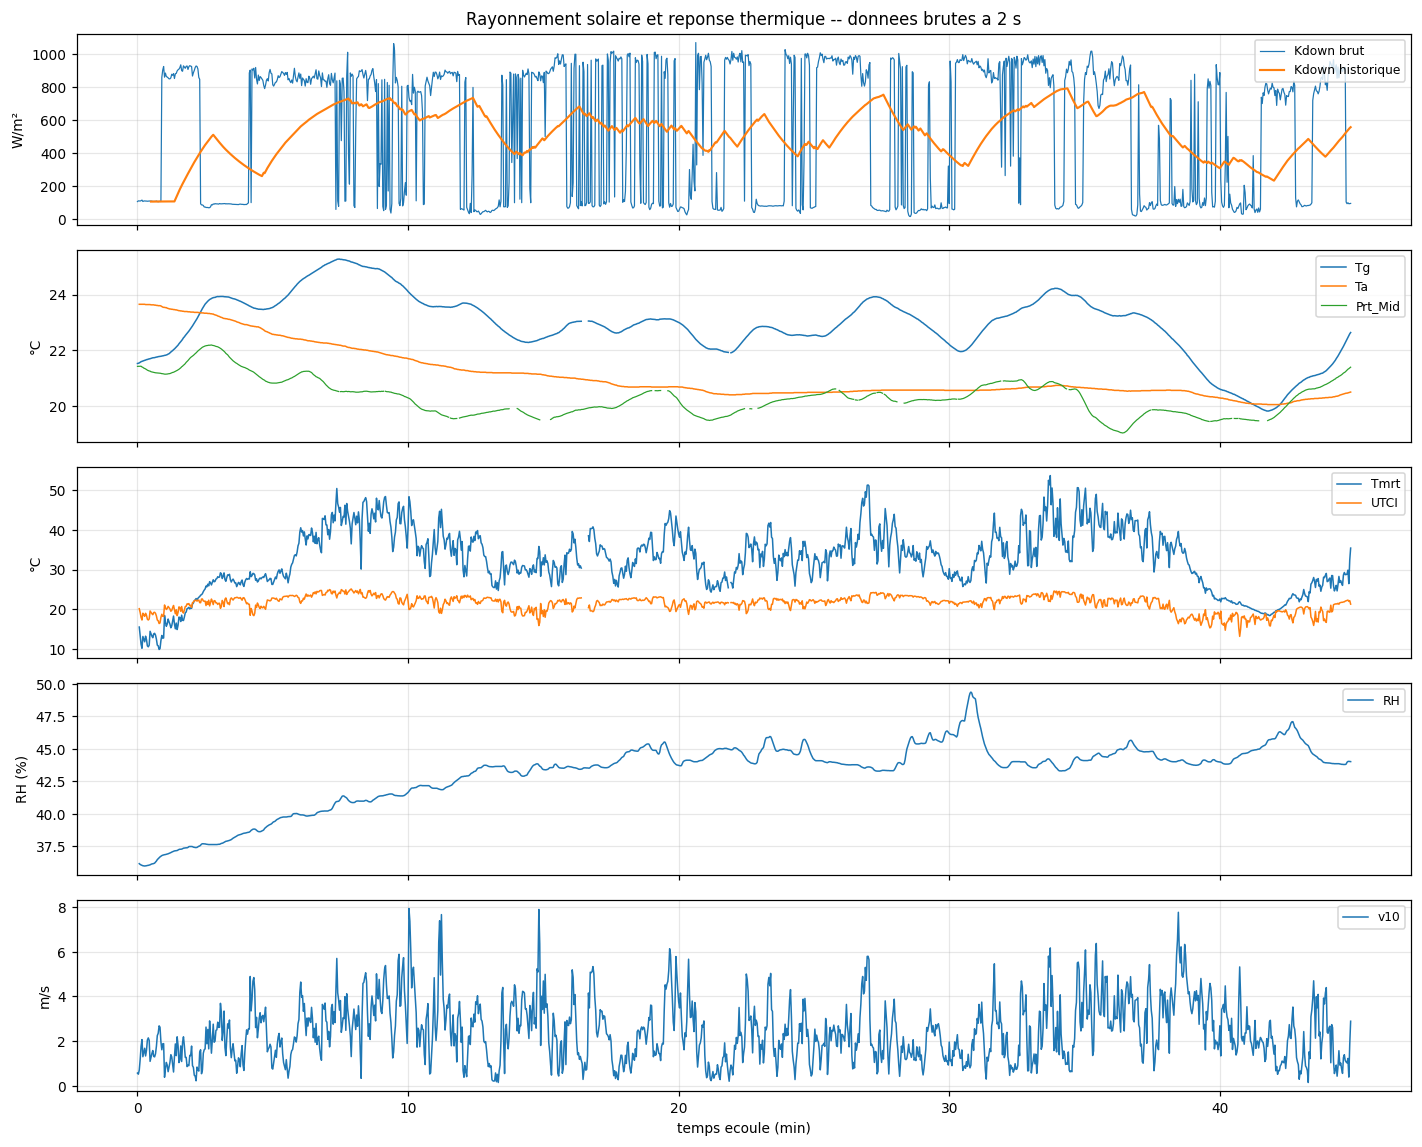

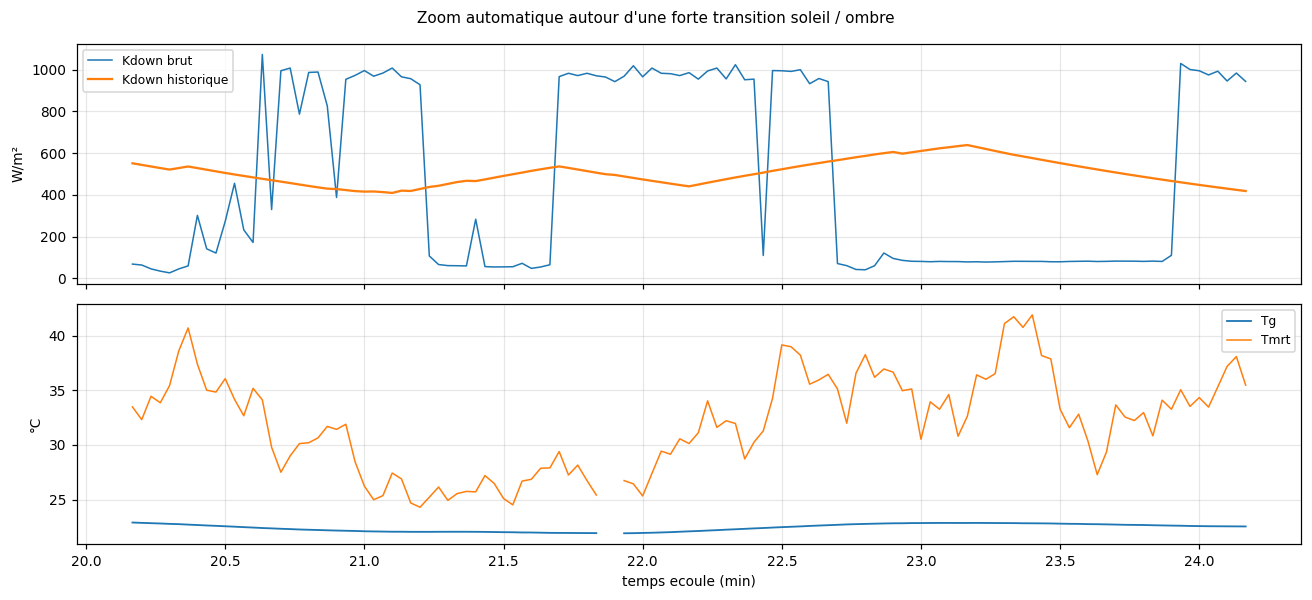

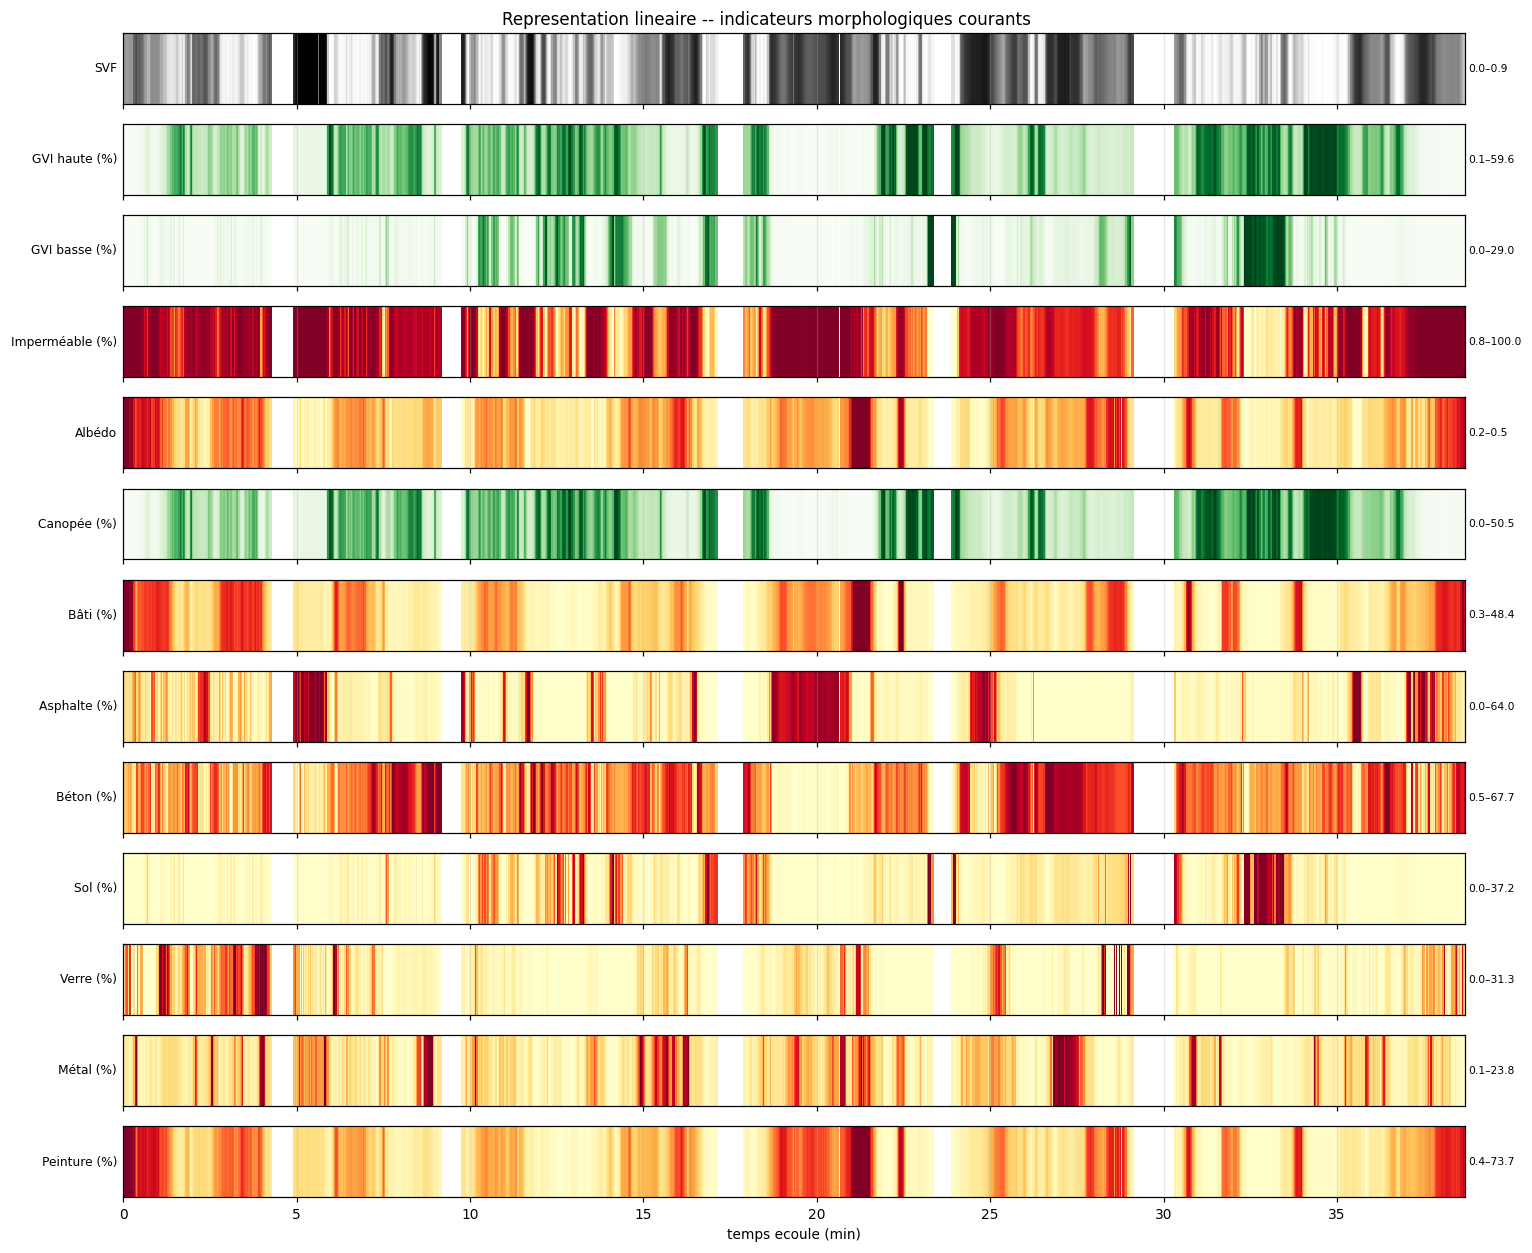

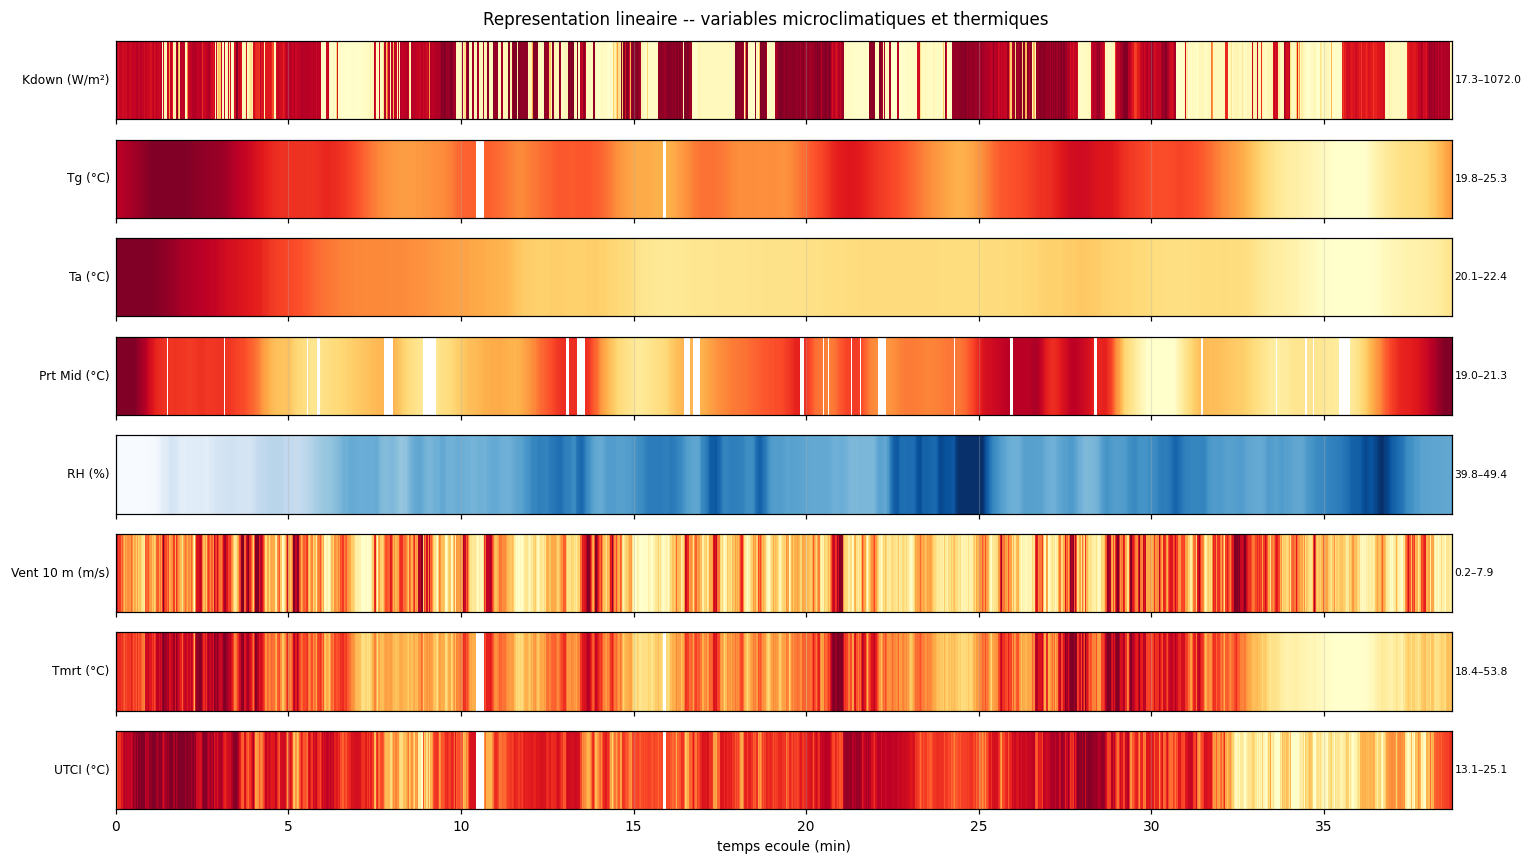

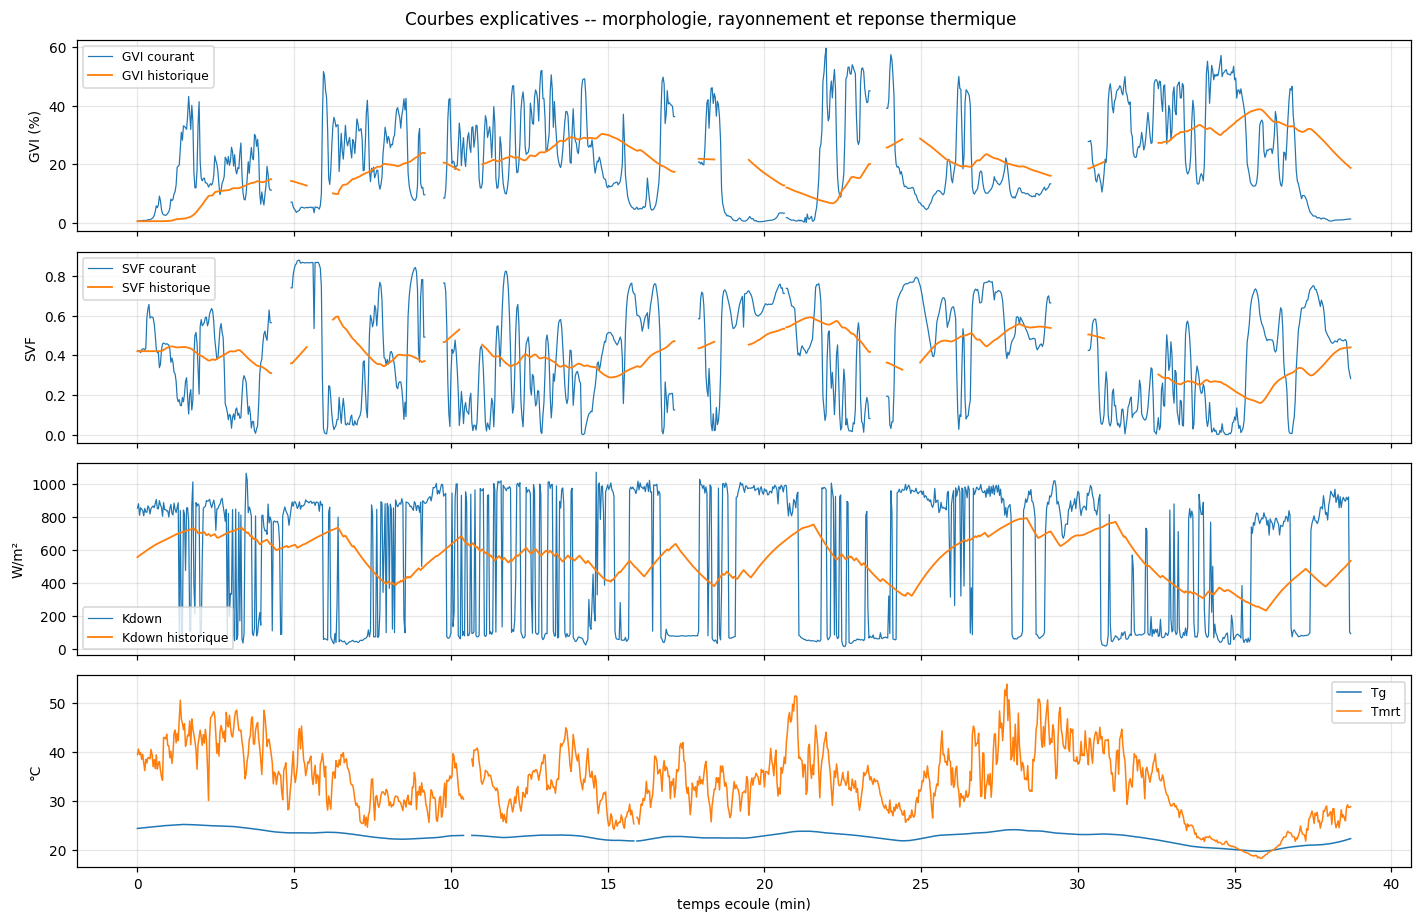

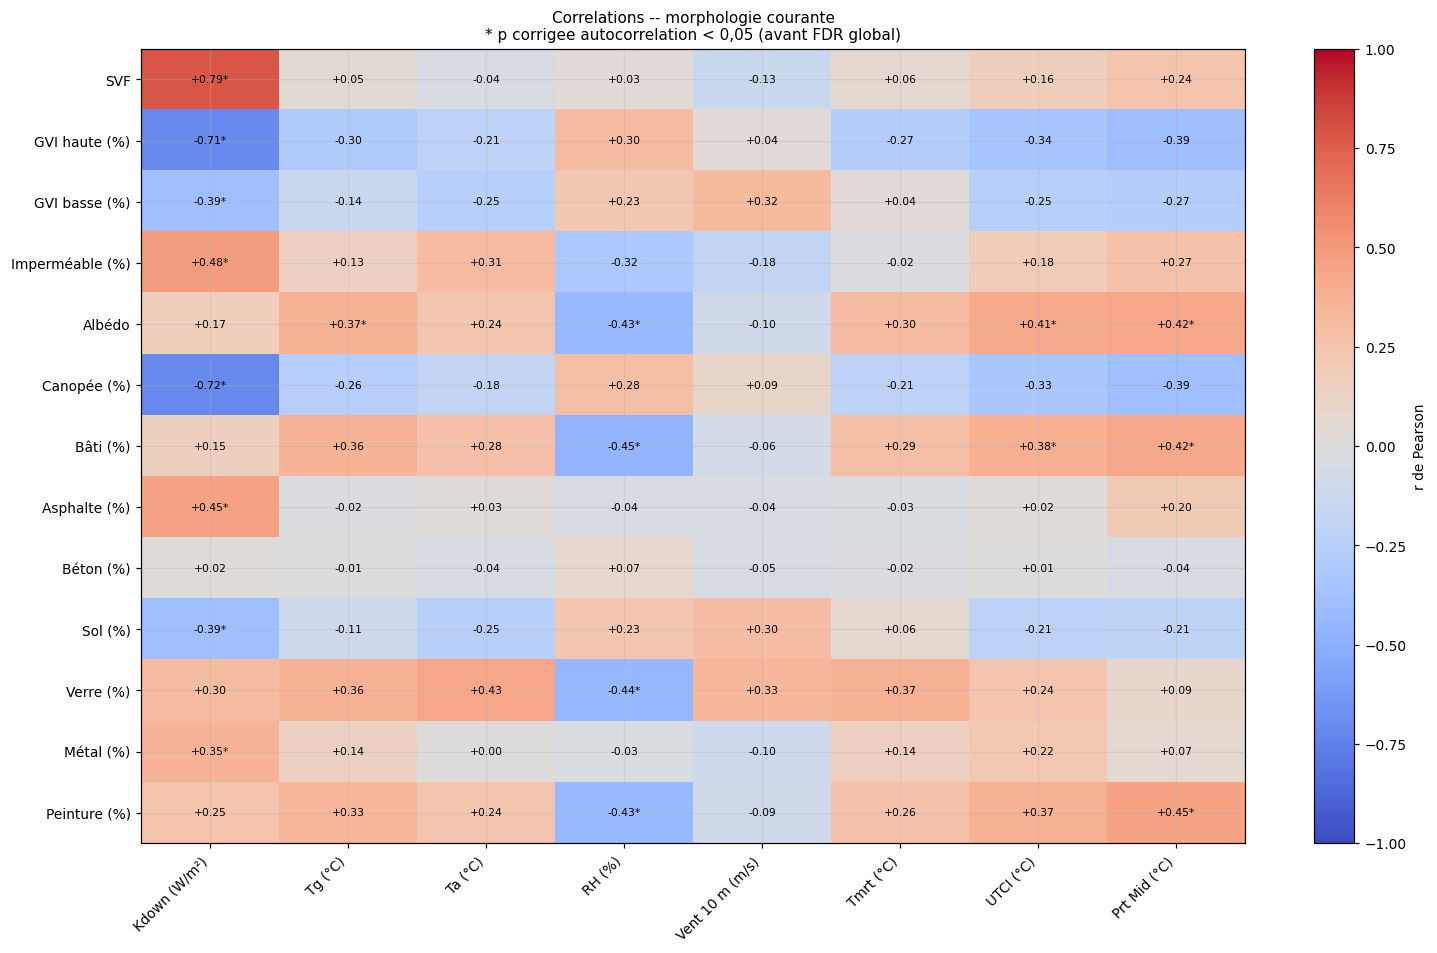

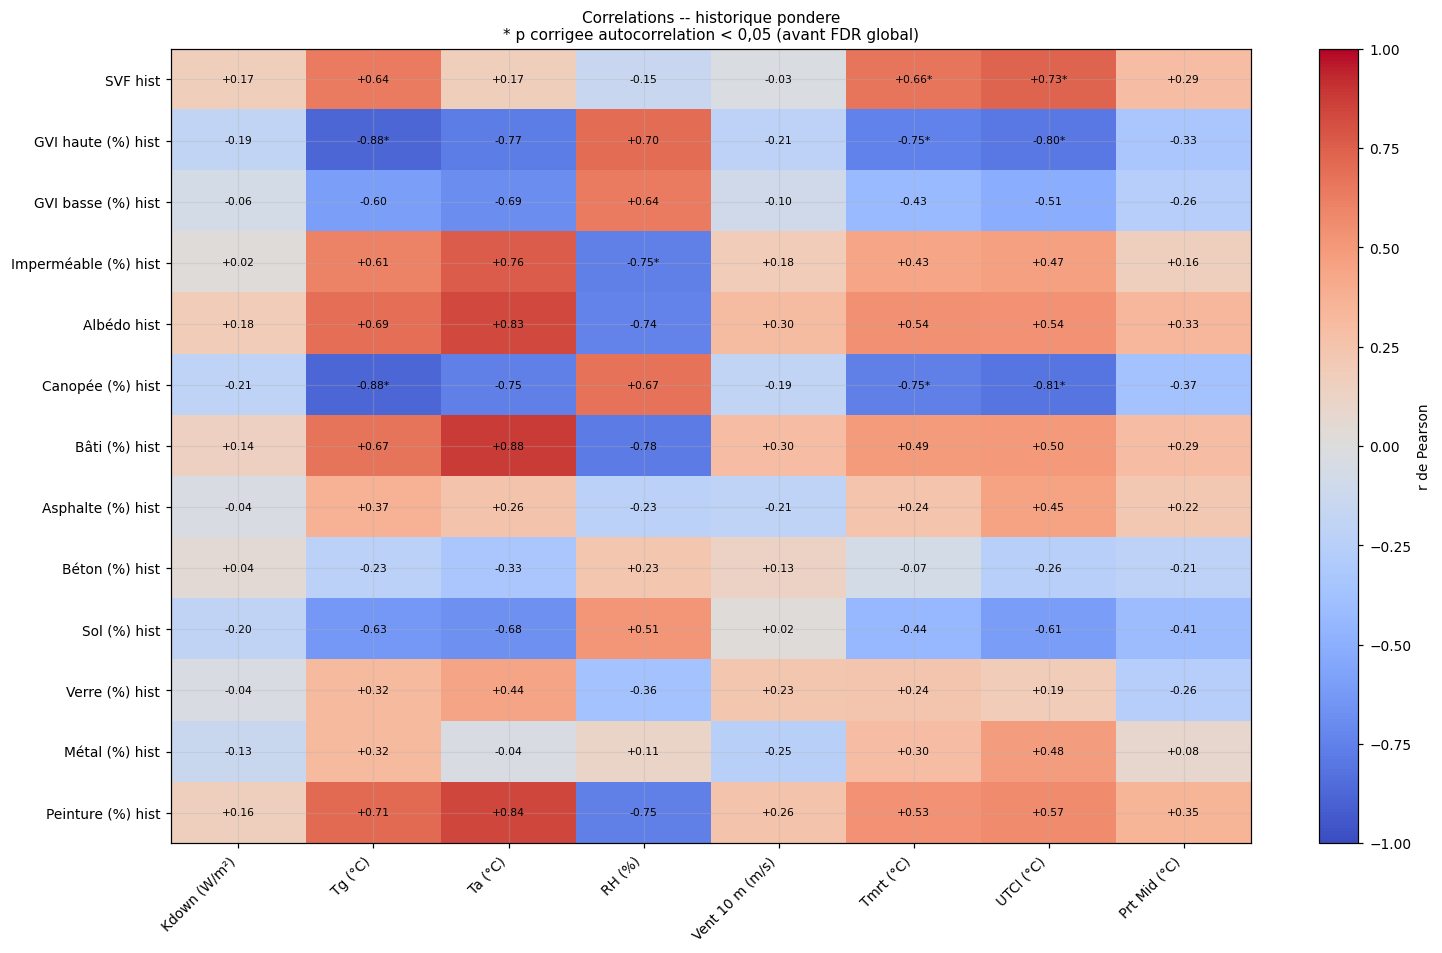

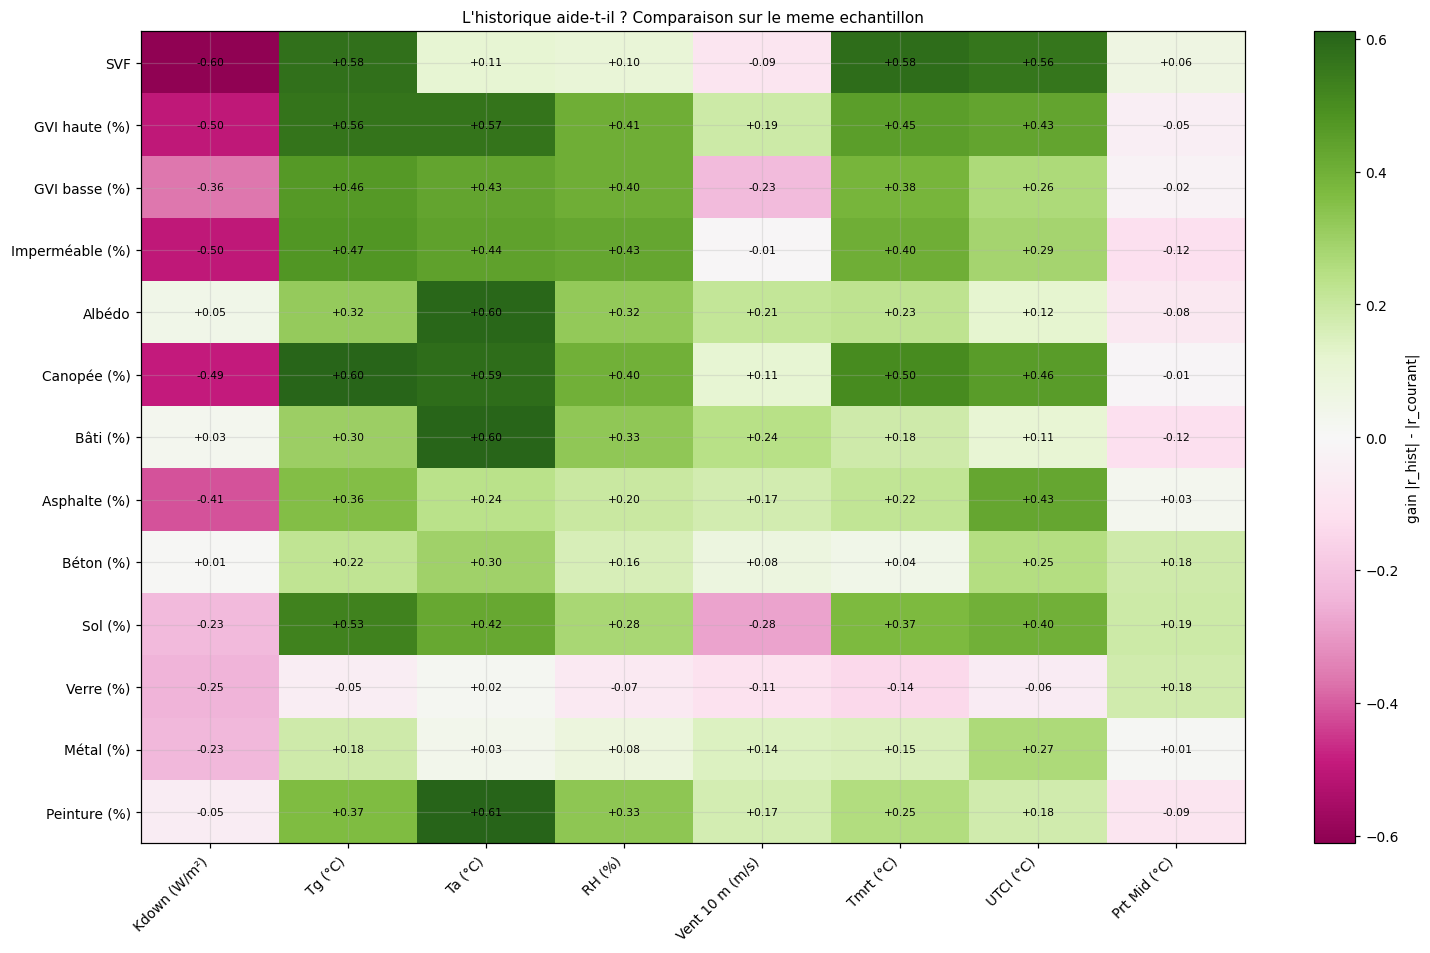

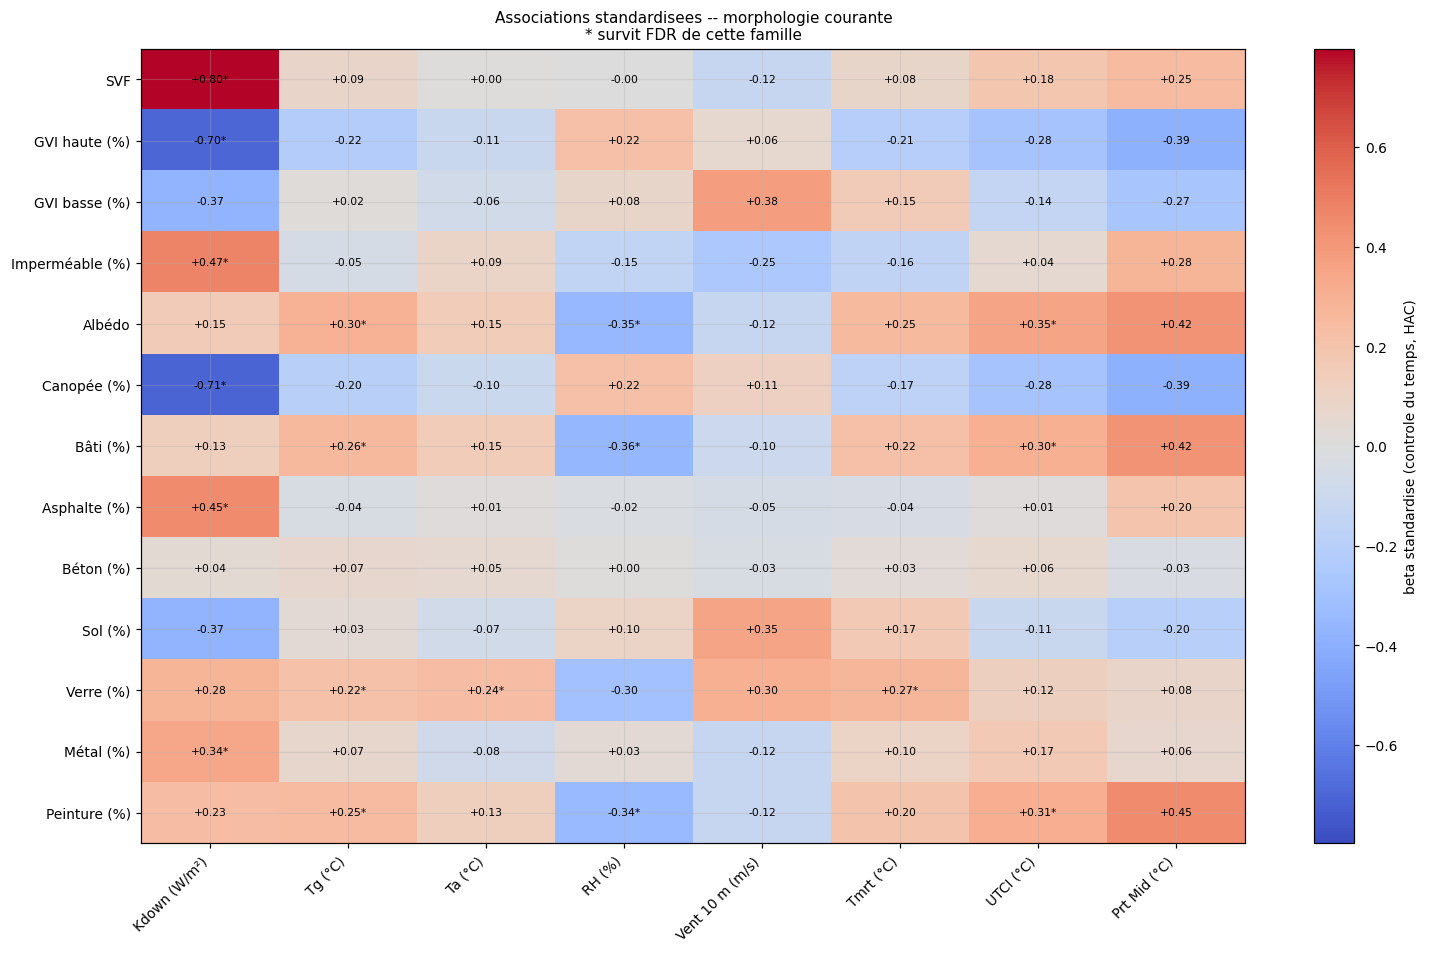

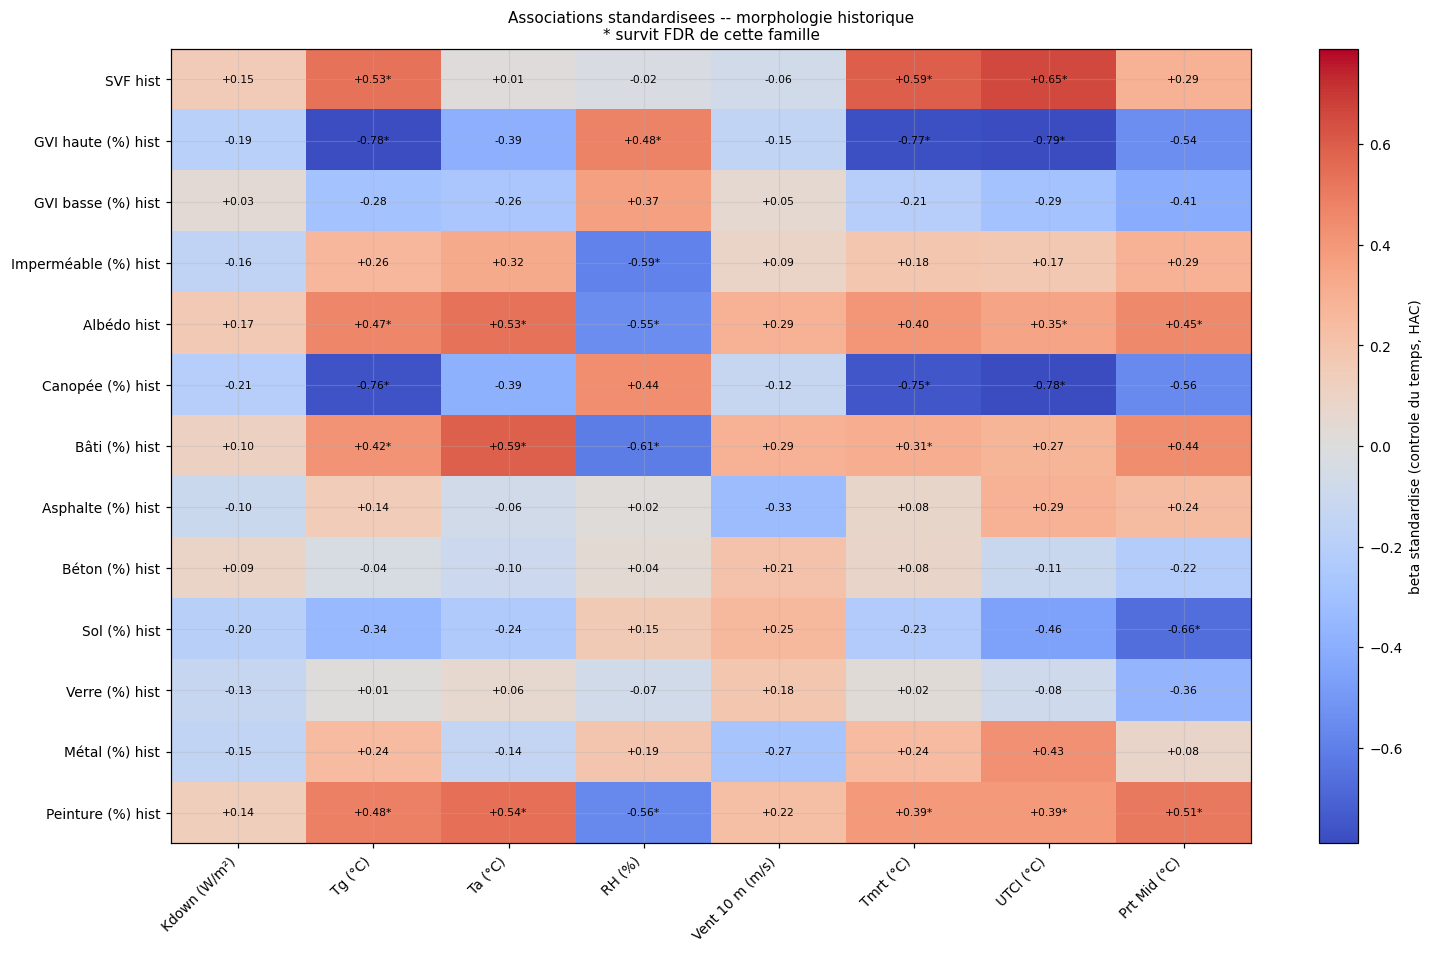

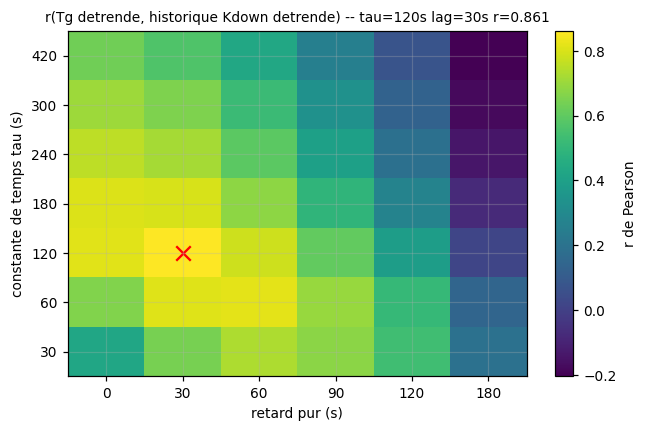

Figures V8 ecrites dans C:\Users\youss\Downloads\coolpath_local\data\outputs\correlation_v8_visualisation_complete\viz


In [18]:
# =============================================================================
# F1 -- RAYONNEMENT BRUT (2 s) ET REPONSE DU GLOBE
# =============================================================================
fig, axes = plt.subplots(5, 1, figsize=(13, 10.5), sharex=True)
axes[0].plot(cp.t_min, cp.Kdown, lw=0.8, label="Kdown brut")
if "Kdown_hist" in cp:
    axes[0].plot(cp.t_min, cp.Kdown_hist, lw=1.4, label="Kdown historique")
axes[0].set_ylabel("W/m²"); axes[0].legend(loc="upper right", fontsize=8)
axes[0].set_title("Rayonnement solaire et reponse thermique -- donnees brutes a 2 s")

axes[1].plot(cp.t_min, cp.Tg, lw=1.0, label="Tg")
axes[1].plot(cp.t_min, cp.Ta, lw=1.0, label="Ta")
if "Prt_Mid" in cp:
    axes[1].plot(cp.t_min, cp.Prt_Mid, lw=0.8, label="Prt_Mid")
axes[1].set_ylabel("°C"); axes[1].legend(loc="upper right", fontsize=8)

if "Tmrt" in cp:
    axes[2].plot(cp.t_min, cp.Tmrt, lw=1.0, label="Tmrt")
if "UTCI" in cp:
    axes[2].plot(cp.t_min, cp.UTCI, lw=1.0, label="UTCI")
axes[2].set_ylabel("°C"); axes[2].legend(loc="upper right", fontsize=8)

if "RH" in cp:
    axes[3].plot(cp.t_min, cp.RH, lw=1.0, label="RH")
axes[3].set_ylabel("RH (%)"); axes[3].legend(loc="upper right", fontsize=8)

if "v10" in cp:
    axes[4].plot(cp.t_min, cp.v10, lw=1.0, label="v10")
axes[4].set_ylabel("m/s"); axes[4].set_xlabel("temps ecoule (min)")
axes[4].legend(loc="upper right", fontsize=8)
fig.savefig(VIZ_DIR / "F1_rayonnement_brut_et_reponse.png", dpi=170, bbox_inches="tight")
plt.show()

# =============================================================================
# F2 -- ZOOM AUTOMATIQUE SUR UNE TRANSITION FORTE DE KDOWN
# =============================================================================
k = cp.Kdown.to_numpy(float)
# cherche le plus fort changement sur ~30 s, plus interpretable qu'un seul bruit de 2 s
pas30 = max(1, int(round(30 / dt_cp)))
variation = np.abs(pd.Series(k).rolling(pas30, min_periods=2).mean().diff(pas30).to_numpy())
if np.isfinite(variation).any():
    ic = int(np.nanargmax(variation))
    centre = cp.t_min.iloc[ic]
    masque_zoom = cp.t_min.between(max(cp.t_min.min(), centre-2.0), min(cp.t_min.max(), centre+2.0))
    z = cp.loc[masque_zoom]
    fig, axes = plt.subplots(2, 1, figsize=(12, 5.5), sharex=True)
    axes[0].plot(z.t_min, z.Kdown, lw=1.0, label="Kdown brut")
    if "Kdown_hist" in z:
        axes[0].plot(z.t_min, z.Kdown_hist, lw=1.5, label="Kdown historique")
    axes[0].set_ylabel("W/m²"); axes[0].legend(fontsize=8)
    axes[1].plot(z.t_min, z.Tg, lw=1.2, label="Tg")
    if "Tmrt" in z:
        axes[1].plot(z.t_min, z.Tmrt, lw=1.0, label="Tmrt")
    axes[1].set_ylabel("°C"); axes[1].set_xlabel("temps ecoule (min)")
    axes[1].legend(fontsize=8)
    fig.suptitle("Zoom automatique autour d'une forte transition soleil / ombre", fontsize=10)
    fig.savefig(VIZ_DIR / "F2_zoom_transition_kdown.png", dpi=170, bbox_inches="tight")
    plt.show()

# =============================================================================
# F3 -- REPRESENTATION LINEAIRE TYPE 'THEO' SUR UN AXE TEMPOREL COMMUN
# =============================================================================
# Grille reguliere de 2 s. Les trous sans image restent NaN (donc blancs dans la figure).
t0_vis = max(cp.ts.min(), ind.ts.min())
t1_vis = min(cp.ts.max(), ind.ts.max())
grille_ts = pd.DataFrame({"ts": pd.date_range(t0_vis, t1_vis, freq="2s")})

morph_cols_vis = [c for c in COLS_IND_COURANTS if c in ind.columns]
cap_cols_vis = [c for c in ["Kdown", "Tg", "Ta", "Prt_Mid", "RH", "v10", "Tmrt", "UTCI"] if c in cp.columns]

vis = pd.merge_asof(grille_ts.sort_values("ts"),
                    ind[["ts"] + morph_cols_vis].sort_values("ts"),
                    on="ts", direction="nearest", tolerance=pd.Timedelta(seconds=2.1))
vis = pd.merge_asof(vis.sort_values("ts"),
                    cp[["ts"] + cap_cols_vis].sort_values("ts"),
                    on="ts", direction="nearest", tolerance=pd.Timedelta(seconds=2.1))
vis["t_min"] = (vis.ts - vis.ts.min()).dt.total_seconds() / 60

LABELS = {
    "SVF":"SVF", "GVI_haute_pct":"GVI haute (%)", "GVI_basse_pct":"GVI basse (%)",
    "taux_impermeable_pct":"Imperméable (%)", "taux_bati_pct":"Bâti (%)",
    "albedo_moyen":"Albédo", "canopee_sol_non_observable_pct":"Canopée (%)",
    "pct_Asphalt":"Asphalte (%)", "pct_Cement_Concrete":"Béton (%)", "pct_Soil_Mud":"Sol (%)",
    "pct_Glass":"Verre (%)", "pct_Metal":"Métal (%)", "pct_Paint":"Peinture (%)",
    "Kdown":"Kdown (W/m²)", "Tg":"Tg (°C)", "Ta":"Ta (°C)", "RH":"RH (%)",
    "Prt_Mid":"Prt Mid (°C)", "v10":"Vent 10 m (m/s)", "Tmrt":"Tmrt (°C)", "UTCI":"UTCI (°C)"
}

def _strip_plot(df, cols, titre, fichier):
    cols = [c for c in cols if c in df.columns and df[c].notna().any()]
    if not cols:
        return
    fig, axes = plt.subplots(len(cols), 1, figsize=(14, 0.72*len(cols)+2.2), sharex=True)
    axes = np.atleast_1d(axes)
    for ax, col in zip(axes, cols):
        arr = df[col].to_numpy(float)
        finite = arr[np.isfinite(arr)]
        if len(finite) == 0:
            continue
        lo, hi = np.nanpercentile(finite, [2, 98])
        if hi <= lo:
            lo, hi = np.nanmin(finite), np.nanmax(finite) + 1e-9
        cmap = "Greens" if "GVI" in col or "canopee" in col else (
               "Blues" if col == "RH" else (
               "Greys" if col == "SVF" else "YlOrRd"))
        data = np.ma.masked_invalid(arr[None, :])
        ax.imshow(data, aspect="auto", interpolation="nearest", cmap=cmap,
                  vmin=lo, vmax=hi,
                  extent=[df.t_min.min(), df.t_min.max(), 0, 1])
        ax.set_yticks([])
        ax.set_ylabel(LABELS.get(col,col), rotation=0, ha="right", va="center", fontsize=8)
        ax.text(1.002, 0.5, f"{np.nanmin(arr):.1f}–{np.nanmax(arr):.1f}",
                transform=ax.transAxes, va="center", fontsize=7)
    axes[-1].set_xlabel("temps ecoule (min)")
    fig.suptitle(titre, fontsize=11)
    fig.savefig(VIZ_DIR / fichier, dpi=180, bbox_inches="tight")
    plt.show()

_strip_plot(vis, morph_cols_vis,
            "Representation lineaire -- indicateurs morphologiques courants",
            "F3a_bandes_morphologie.png")
_strip_plot(vis, cap_cols_vis,
            "Representation lineaire -- variables microclimatiques et thermiques",
            "F3b_bandes_microclimat.png")

# F3c -- courbes explicatives : morphologie courante/historique + rayonnement/temperature
courbes_cols = [c for c in ["SVF", "SVF_hist", "GVI_haute_pct", "GVI_haute_pct_hist"] if c in ind.columns]
vis_h = pd.merge_asof(grille_ts.sort_values("ts"),
                      ind[["ts"] + courbes_cols].sort_values("ts"),
                      on="ts", direction="nearest", tolerance=pd.Timedelta(seconds=2.1))
vis_h = pd.merge_asof(vis_h.sort_values("ts"),
                      cp[["ts"] + [c for c in ["Kdown","Kdown_hist","Tg","Tmrt"] if c in cp.columns]].sort_values("ts"),
                      on="ts", direction="nearest", tolerance=pd.Timedelta(seconds=2.1))
vis_h["t_min"] = (vis_h.ts - vis_h.ts.min()).dt.total_seconds()/60
fig, axes = plt.subplots(4, 1, figsize=(13, 8.5), sharex=True)
if "GVI_haute_pct" in vis_h:
    axes[0].plot(vis_h.t_min, vis_h.GVI_haute_pct, lw=0.8, label="GVI courant")
if "GVI_haute_pct_hist" in vis_h:
    axes[0].plot(vis_h.t_min, vis_h.GVI_haute_pct_hist, lw=1.2, label="GVI historique")
axes[0].set_ylabel("GVI (%)"); axes[0].legend(fontsize=8)
if "SVF" in vis_h:
    axes[1].plot(vis_h.t_min, vis_h.SVF, lw=0.8, label="SVF courant")
if "SVF_hist" in vis_h:
    axes[1].plot(vis_h.t_min, vis_h.SVF_hist, lw=1.2, label="SVF historique")
axes[1].set_ylabel("SVF"); axes[1].legend(fontsize=8)
if "Kdown" in vis_h:
    axes[2].plot(vis_h.t_min, vis_h.Kdown, lw=0.8, label="Kdown")
if "Kdown_hist" in vis_h:
    axes[2].plot(vis_h.t_min, vis_h.Kdown_hist, lw=1.2, label="Kdown historique")
axes[2].set_ylabel("W/m²"); axes[2].legend(fontsize=8)
if "Tg" in vis_h:
    axes[3].plot(vis_h.t_min, vis_h.Tg, lw=1.0, label="Tg")
if "Tmrt" in vis_h:
    axes[3].plot(vis_h.t_min, vis_h.Tmrt, lw=1.0, label="Tmrt")
axes[3].set_ylabel("°C"); axes[3].set_xlabel("temps ecoule (min)"); axes[3].legend(fontsize=8)
fig.suptitle("Courbes explicatives -- morphologie, rayonnement et reponse thermique", fontsize=11)
fig.savefig(VIZ_DIR / "F3c_courbes_morphologie_rayonnement.png", dpi=180, bbox_inches="tight")
plt.show()

# =============================================================================
# F4 -- HEATMAP DES CORRELATIONS : TOUS INDICATEURS x TOUTES CIBLES (60 s)
# =============================================================================
def _heatmap_corr(indics, titre, fichier):
    indics = [c for c in indics if c in vue.indicateur.unique()]
    cibles = [c for c in CIBLES if c in vue.cible.unique() and c != "Kdown_hist"]
    if not indics or not cibles:
        return
    piv = vue.pivot_table(index="indicateur", columns="cible", values="r").reindex(index=indics, columns=cibles)
    pp = vue.pivot_table(index="indicateur", columns="cible", values="p_corrigee").reindex(index=indics, columns=cibles)
    fig, ax = plt.subplots(figsize=(1.25*len(cibles)+4, 0.48*len(indics)+2.5))
    im = ax.imshow(piv.to_numpy(float), aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_xticks(range(len(cibles)), [LABELS.get(c,c) for c in cibles], rotation=45, ha="right")
    ax.set_yticks(range(len(indics)), [LABELS.get(i.replace("_hist",""),i) + (" hist" if i.endswith("_hist") else "") for i in indics])
    for ii in range(len(indics)):
        for jj in range(len(cibles)):
            val = piv.iloc[ii,jj]
            if np.isfinite(val):
                star = "*" if np.isfinite(pp.iloc[ii,jj]) and pp.iloc[ii,jj] < 0.05 else ""
                ax.text(jj, ii, f"{val:+.2f}{star}", ha="center", va="center", fontsize=7)
    fig.colorbar(im, ax=ax, label="r de Pearson")
    ax.set_title(titre + "\n* p corrigee autocorrelation < 0,05 (avant FDR global)", fontsize=10)
    fig.savefig(VIZ_DIR / fichier, dpi=180, bbox_inches="tight")
    plt.show()

_heatmap_corr(COLS_IND_COURANTS, "Correlations -- morphologie courante", "F4a_heatmap_courante.png")
_heatmap_corr(COLS_HIST, "Correlations -- historique pondere", "F4b_heatmap_historique.png")

# =============================================================================
# F5 -- GAIN DE L'HISTORIQUE SUR LE MEME ECHANTILLON
# =============================================================================
if len(cmp_hist):
    cibles_gain = [c for c in CIBLES_HIST_COMPARAISON if c in cmp_hist.cible.unique()]
    indic_gain = [c for c in MORPHO_A_HISTORISER if c in cmp_hist.indicateur.unique()]
    pivg = cmp_hist.pivot_table(index="indicateur", columns="cible", values="gain_abs").reindex(index=indic_gain, columns=cibles_gain)
    fig, ax = plt.subplots(figsize=(1.25*len(cibles_gain)+4, 0.48*len(indic_gain)+2.5))
    vmax = np.nanmax(np.abs(pivg.to_numpy(float)))
    im = ax.imshow(pivg.to_numpy(float), aspect="auto", cmap="PiYG", vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(len(cibles_gain)), [LABELS.get(c,c) for c in cibles_gain], rotation=45, ha="right")
    ax.set_yticks(range(len(indic_gain)), [LABELS.get(i,i) for i in indic_gain])
    for ii in range(len(indic_gain)):
        for jj in range(len(cibles_gain)):
            val = pivg.iloc[ii,jj]
            if np.isfinite(val):
                ax.text(jj, ii, f"{val:+.2f}", ha="center", va="center", fontsize=7)
    fig.colorbar(im, ax=ax, label="gain |r_hist| - |r_courant|")
    ax.set_title("L'historique aide-t-il ? Comparaison sur le meme echantillon", fontsize=10)
    fig.savefig(VIZ_DIR / "F5_gain_historique_heatmap.png", dpi=180, bbox_inches="tight")
    plt.show()

# =============================================================================
# F6 -- ASSOCIATIONS STANDARDISEES HAC
# =============================================================================
if 'effets' in globals() and len(effets):
    # Deux figures separees pour rester lisibles
    for version, fichier in [("courante","F6a_beta_standardise_courant.png"),
                             ("historique","F6b_beta_standardise_historique.png")]:
        e = effets[effets.version == version].copy()
        indics = [c for c in (COLS_IND_COURANTS if version=="courante" else COLS_HIST)
                  if c in e.indicateur.unique()]
        cibles = [c for c in CIBLES_EFFETS if c in e.cible.unique()]
        if not indics or not cibles:
            continue
        piv = e.pivot_table(index="indicateur", columns="cible", values="beta_std").reindex(index=indics, columns=cibles)
        qv = e.pivot_table(index="indicateur", columns="cible", values="q_value").reindex(index=indics, columns=cibles)
        vmax = max(0.2, np.nanmax(np.abs(piv.to_numpy(float))))
        fig, ax = plt.subplots(figsize=(1.25*len(cibles)+4, 0.48*len(indics)+2.5))
        im = ax.imshow(piv.to_numpy(float), aspect="auto", cmap="coolwarm", vmin=-vmax, vmax=vmax)
        ax.set_xticks(range(len(cibles)), [LABELS.get(c,c) for c in cibles], rotation=45, ha="right")
        ax.set_yticks(range(len(indics)), [LABELS.get(i.replace("_hist",""),i) + (" hist" if version=="historique" else "") for i in indics])
        for ii in range(len(indics)):
            for jj in range(len(cibles)):
                val = piv.iloc[ii,jj]
                if np.isfinite(val):
                    star = "*" if np.isfinite(qv.iloc[ii,jj]) and qv.iloc[ii,jj] < 0.05 else ""
                    ax.text(jj, ii, f"{val:+.2f}{star}", ha="center", va="center", fontsize=7)
        fig.colorbar(im, ax=ax, label="beta standardise (controle du temps, HAC)")
        ax.set_title(f"Associations standardisees -- morphologie {version}\n* survit FDR de cette famille", fontsize=10)
        fig.savefig(VIZ_DIR / fichier, dpi=180, bbox_inches="tight")
        plt.show()

# =============================================================================
# F7 -- CALIBRATION TAU/LAG (conservee de V7)
# =============================================================================
fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(grille.to_numpy(float), aspect="auto", origin="lower", cmap="viridis")
ax.set_xticks(range(len(LAGS)), [str(l) for l in LAGS])
ax.set_yticks(range(len(TAUS)), [str(t) for t in TAUS])
ax.set_xlabel("retard pur (s)"); ax.set_ylabel("constante de temps tau (s)")
ax.set_title(f"r(Tg detrende, historique Kdown detrende) -- tau={TAU_OPT}s lag={LAG_OPT}s r={r_opt:.3f}", fontsize=9)
ax.scatter(LAGS.index(LAG_OPT), TAUS.index(TAU_OPT), marker="x", s=90, c="red")
fig.colorbar(im, ax=ax, label="r de Pearson")
fig.savefig(VIZ_DIR / "F7_calibration_tau_lag.png", dpi=170, bbox_inches="tight")
plt.show()

print(f"Figures V8 ecrites dans {VIZ_DIR}")


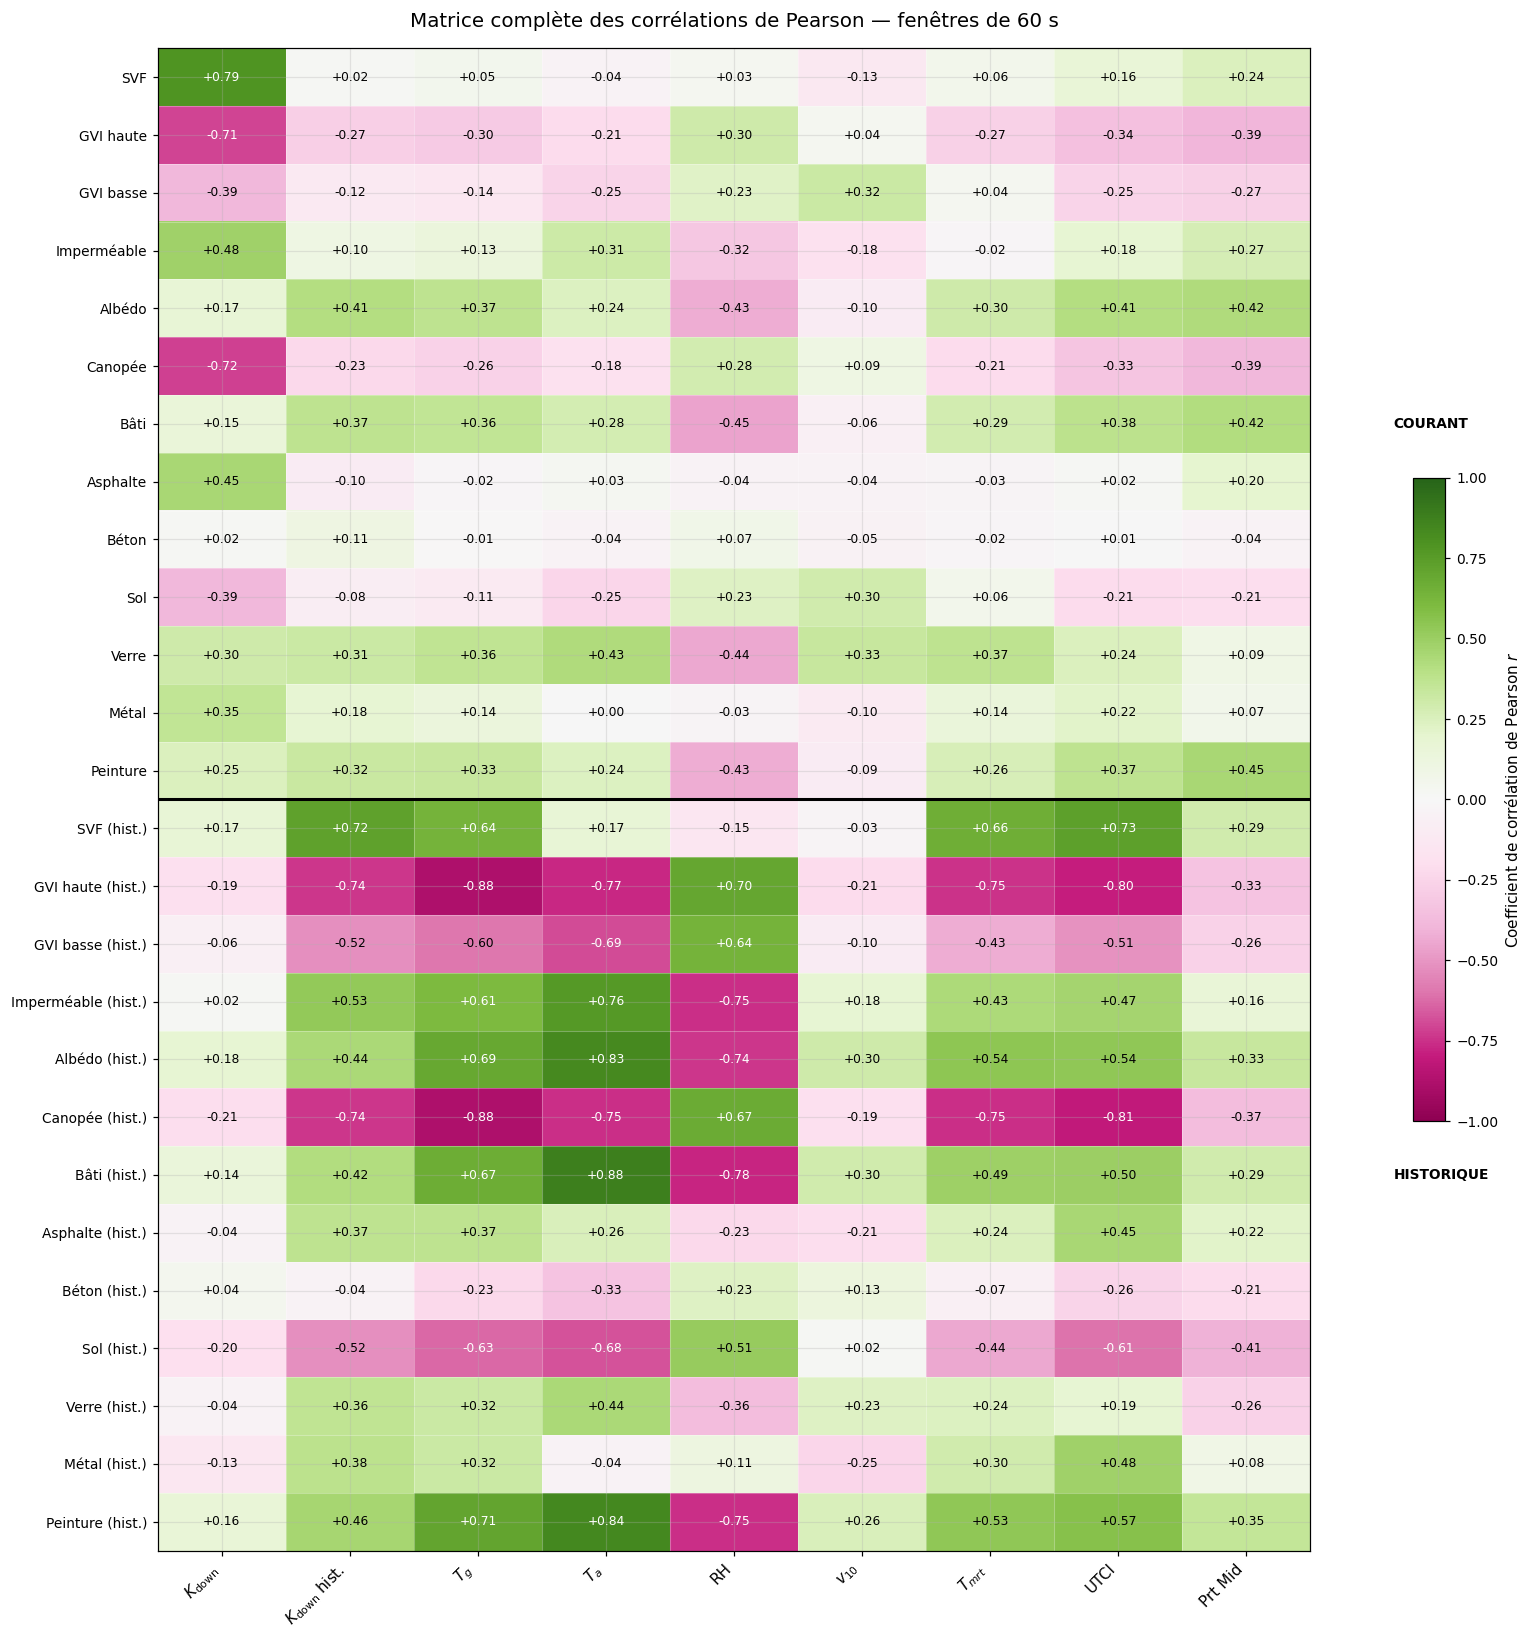

Figure enregistrée : C:\Users\youss\Downloads\coolpath_local\data\outputs\correlation_v8_visualisation_complete\viz\F_finale_matrice_correlations_complete.png


In [19]:
# =============================================================================
# FIGURE FINALE -- MATRICE COMPLETE DES CORRELATIONS
# Indicateurs courants + historiques × variables microclimatiques
# Pearson r, à la fenêtre temporelle principale
# =============================================================================

# Données de la fenêtre principale
df_corr = mat[mat["fenetre_s"] == FENETRE_REF].copy()

# Ordre des lignes
ordre_indicateurs = [
    c for c in (COLS_IND_COURANTS + COLS_HIST)
    if c in df_corr["indicateur"].unique()
]

# Ordre des colonnes
ordre_cibles = [
    c for c in [
        "Kdown", "Kdown_hist",
        "Tg", "Ta", "RH", "v10",
        "Tmrt", "UTCI", "Prt_Mid"
    ]
    if c in df_corr["cible"].unique()
]

# Matrice Pearson
M = (
    df_corr
    .pivot(index="indicateur", columns="cible", values="r")
    .reindex(index=ordre_indicateurs, columns=ordre_cibles)
)

# Labels lisibles
labels_ind = {
    "SVF": "SVF",
    "GVI_haute_pct": "GVI haute",
    "GVI_basse_pct": "GVI basse",
    "taux_impermeable_pct": "Imperméable",
    "albedo_moyen": "Albédo",
    "canopee_sol_non_observable_pct": "Canopée",
    "taux_bati_pct": "Bâti",
    "pct_Asphalt": "Asphalte",
    "pct_Cement_Concrete": "Béton",
    "pct_Soil_Mud": "Sol",
    "pct_Glass": "Verre",
    "pct_Metal": "Métal",
    "pct_Paint": "Peinture",
}

labels_cibles = {
    "Kdown": r"$K_{\mathrm{down}}$",
    "Kdown_hist": r"$K_{\mathrm{down}}$ hist.",
    "Tg": r"$T_g$",
    "Ta": r"$T_a$",
    "RH": "RH",
    "v10": r"$v_{10}$",
    "Tmrt": r"$T_{mrt}$",
    "UTCI": "UTCI",
    "Prt_Mid": "Prt Mid",
}

def label_indicateur(c):
    if c.endswith("_hist"):
        base = c[:-5]
        return labels_ind.get(base, base) + " (hist.)"
    return labels_ind.get(c, c)

# -------------------------------------------------------------------------
# Figure
# -------------------------------------------------------------------------
fig_h = max(9, 0.48 * len(M.index) + 2.5)

fig, ax = plt.subplots(figsize=(14, fig_h))

im = ax.imshow(
    M.to_numpy(dtype=float),
    cmap="PiYG",
    vmin=-1,
    vmax=1,
    aspect="auto"
)

# Axes
ax.set_xticks(np.arange(len(M.columns)))
ax.set_xticklabels(
    [labels_cibles.get(c, c) for c in M.columns],
    rotation=45,
    ha="right",
    fontsize=10
)

ax.set_yticks(np.arange(len(M.index)))
ax.set_yticklabels(
    [label_indicateur(c) for c in M.index],
    fontsize=9
)

# Valeurs dans les cases
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        val = M.iloc[i, j]
        if np.isfinite(val):
            couleur = "white" if abs(val) >= 0.60 else "black"
            ax.text(
                j, i,
                f"{val:+.2f}",
                ha="center",
                va="center",
                fontsize=8,
                color=couleur
            )

# Séparation courant / historique
n_courants = sum(c in M.index for c in COLS_IND_COURANTS)

if 0 < n_courants < len(M.index):
    ax.axhline(
        n_courants - 0.5,
        color="black",
        linewidth=2
    )

    ax.text(
        len(M.columns) + 0.15,
        (n_courants - 1) / 2,
        "COURANT",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

    ax.text(
        len(M.columns) + 0.15,
        n_courants + (len(M.index) - n_courants - 1) / 2,
        "HISTORIQUE",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

# Grille
ax.set_xticks(np.arange(-0.5, len(M.columns), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(M.index), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=0.7)
ax.tick_params(which="minor", bottom=False, left=False)

ax.set_title(
    f"Matrice complète des corrélations de Pearson — fenêtres de {FENETRE_REF} s",
    fontsize=13,
    pad=14
)

# Barre de couleur
cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.08)
cbar.set_label("Coefficient de corrélation de Pearson $r$", fontsize=10)

plt.tight_layout()

# Sauvegarde
fichier = VIZ_DIR / "F_finale_matrice_correlations_complete.png"
fig.savefig(fichier, dpi=220, bbox_inches="tight")

plt.show()

print(f"Figure enregistrée : {fichier}")

## 14. Synthèse V8 et règles d’interprétation

### Ce que la V8 ajoute

1. **Courbes explicatives à 2 s** : `Kdown`, `Kdown_hist`, `Tg`, `Ta`, `Tmrt`, `UTCI`, `RH` et `v10`.
2. **Représentations linéaires temporelles** sur le principe montré en réunion, pour observer
   directement les co-évolutions morphologie–microclimat.
3. **Historique pondéré pour tous les indicateurs morphologiques** disponibles, avec le même
   `tau` et le même retard calibrés sur Kdown→Tg, sans ré-optimisation.
4. **Cibles élargies** : rayonnement, températures (`Tg`, `Ta`, `Tmrt`), humidité (`RH`), vent
   (`v10`) et UTCI. La direction du vent n’est pas traitée par Pearson/Spearman classique car elle
   est circulaire.
5. **Comparaison courant vs historique sur le même échantillon** pour chaque indicateur et chaque
   cible, afin de mesurer si l’historique améliore réellement `|r|`.
6. **Association standardisée HAC** indicateur par indicateur, contrôlée par le temps, avec IC95 %
   et FDR. C’est la réponse quantitative à « quel indicateur est le plus associé à quelle variable ? ».

### Règles de lecture

- Les courbes et bandes à 2 s sont **descriptives** : elles servent à voir les passages soleil/ombre
  et les co-évolutions, pas à augmenter artificiellement N.
- L’inférence principale reste faite sur les fenêtres 30/60/120 s, avec 60 s comme référence.
- `beta_std` est une **association standardisée**, pas un effet causal.
- Une version `_hist` représente un **historique pondéré d’exposition** compatible avec la dynamique
  du globe. Elle ne signifie pas que le matériau ou la ville a une inertie intrinsèque de 120 s.
- Pour GVI/SVF → Tmrt/UTCI, les analyses partielles mécanistiques restent ciblées afin de ne pas
  multiplier sans contrôle les tests de médiation. Les matrices exhaustives sont exploratoires et
  doivent être lues avec leur FDR.

### Limites principales

| Limite | Portée |
|---|---|
| **N ≈ 39 à 60 s** | la durée du parcours borne le nombre d’observations indépendantes ; 1041 frames améliorent surtout la description intra-segment |
| Un seul parcours / une seule journée | pas de généralisation sans réplication |
| `tau`/lag calibrés sur Kdown→Tg | historique utile pour l’alignement avec le capteur, pas preuve d’inertie urbaine |
| Trous entre chapitres | historiques non fiables écartés selon le masque de fiabilité |
| Globe 40 mm, émissivité et profil de vent | prudence sur les valeurs absolues de Tmrt/UTCI |
| Forte colinéarité entre certains indicateurs | ne pas interpréter un grand modèle multivarié comme causal |
| Multiplicité des tests | distinguer exploration exhaustive et tests ciblés guidés par la physique |
